# RESUME AFTER A DISCONNECT — read this first

Colab wipes local disk and unmounts Drive on every reconnect, but
**everything that matters is on Drive**: the archive, the source modules,
the cached arrays, the frozen splits, and every report.

**You do not need to re-download, re-extract, or re-run any experiment.**

Run cell R below, then jump straight to whichever step you were on. Cell R
mounts Drive, rebuilds the paths, and restores the source modules from
`src/` back to local disk — which is what the `%%writefile` cells were doing
anyway.

Only re-run the download and extraction cells (4 and 5) if you need the raw
CSVs, which is nothing after Step 1.

In [1]:
# ---- CELL R: resume after a disconnect ----------------------------------
from google.colab import drive
drive.mount('/content/drive')

import os, sys, shutil, subprocess, json

PROJECT = '/content/drive/MyDrive/radar_compression'
DIRS = {k: os.path.join(PROJECT, k) for k in
        ('archive', 'src', 'cache', 'splits', 'reports', 'figures')}
for d in DIRS.values():
    os.makedirs(d, exist_ok=True)

ZIP_PATH  = os.path.join(DIRS['archive'], 'rdrd.zip')
KAGGLE_JS = os.path.join(DIRS['archive'], 'kaggle.json')
LOCAL_RAW = '/content/rdrd/raw'
LOCAL_SRC = '/content/src'
DATA_DIR  = DIRS['cache']
os.makedirs(LOCAL_SRC, exist_ok=True)

# restore the modules from Drive instead of re-running the writefile cells
restored = []
for f in sorted(os.listdir(DIRS['src'])):
    if f.endswith('.py'):
        shutil.copy(os.path.join(DIRS['src'], f), os.path.join(LOCAL_SRC, f))
        restored.append(f)
print('restored modules:', restored)

print('\nwhat survived on Drive:')
for k in ('archive', 'src', 'cache', 'splits', 'reports', 'figures'):
    items = sorted(os.listdir(DIRS[k]))
    print('  %-9s %s' % (k + '/', ', '.join(items) if items else '(empty)'))

cache = os.path.join(DATA_DIR, 'dataset.npz')
print('\ndataset cache present:', os.path.exists(cache))
if os.path.exists(cache):
    import numpy as np, collections
    d = np.load(cache, allow_pickle=False)
    print('  X', d['X'].shape, '| classes', dict(collections.Counter(d['y'].tolist())))
    print('  units', len(set(d['unit'].tolist())))
print('\nready. Jump to the cell you were on.')

Mounted at /content/drive
restored modules: ['interaction.py', 'rdrd.py', 'run_step1.py', 'step2.py', 'step2b.py', 'step2c.py', 'step2d.py', 'step3.py', 'step4.py', 'step5.py']

what survived on Drive:
  archive/  kaggle.json, rdrd.zip
  src/      interaction.py, rdrd.py, run_step1.py, step2.py, step2b.py, step2c.py, step2d.py, step3.py, step4.py, step5.py
  cache/    dataset.npz, rdrd_cache.npz
  splits/   rdrd_session_report.json, split_grouped.json, split_random.json
  reports/  step1_report.json, step2_compare.json, step2b_kfold.json, step2b_norm.json, step2c_sessions.json, step2d_13-48.json, step3_ablate.json, step3_grid.json, step4_ablate.json, step4_augment.json, step4_seeds.json, step4_seeds10.json, step5_loo.json
  figures/  accuracy_vs_memory.png, compression_grid.png, recall_vs_headroom.png, samples_per_class.png, session_13-48_vs_others.png

dataset cache present: True
  X (17485, 11, 61) | classes {'car': 5720, 'drone': 5065, 'person': 6700}
  units 52

ready. Jump to the 

## Verification

Checks every number the manuscript states against the reports in Drive. It
trains nothing and takes a few seconds. Run it after any stage that writes a
report, and again before cutting a release.

`check_expected.py` reads `expected.json`, which pairs each number in the
paper with the report file and location that produces it, a tolerance, and
the reason for that tolerance. A clean run means the paper and the reports
agree. Claims whose report is absent are listed separately from claims that
disagree, so a partial run cannot look like a clean one.


In [ ]:
# ---- Verification: every number in the paper against the reports ----
import subprocess, sys, os

REPO    = '/content/rdrd-acquisition-coverage'
PROJECT = '/content/drive/MyDrive/radar_compression'

if os.path.isdir(os.path.join(REPO, '.git')):
    subprocess.run(['git', '-C', REPO, 'pull', '--ff-only'],
                   capture_output=True, text=True)
else:
    subprocess.run(['git', 'clone', '--depth', '1',
                    'https://github.com/falcon-colab/'
                    'rdrd-acquisition-coverage', REPO],
                   capture_output=True, text=True, check=True)

print('--- unit tests (no data, no GPU)')
proc = subprocess.run([sys.executable, os.path.join(REPO, 'tests',
                                                    'test_core.py')],
                      capture_output=True, text=True)
print(proc.stdout.strip().splitlines()[-1] if proc.stdout else proc.stderr)

print('\n--- the manuscript against the reports')
proc = subprocess.run(
    [sys.executable, os.path.join(REPO, 'check_expected.py'),
     '--reports', os.path.join(PROJECT, 'reports')],
    capture_output=True, text=True)
print(proc.stdout[-9000:])
if proc.returncode and proc.stderr:
    print(proc.stderr[-2000:])


# Radar Compression Project — Master Notebook

**This is the only notebook you need.** Run it top to bottom once. Everything
earlier is superseded; delete those notebooks.

It creates a fixed folder structure on Drive, downloads the dataset, runs the
full Step 1 pipeline (audit, deduplication, leakage measurement, splits), and
caches the data as a single array file.

---

### Before you start: terminate the old sessions

Colab gives every open notebook its own runtime, and there is **no API to
terminate another notebook's session** from inside this one. It is a menu
action:

> **Runtime → Manage sessions → Terminate** (do this for every session except
> this notebook's)

Cell 1 below verifies you are running in a clean runtime and will tell you if
you are not.

### A note on the duplicated data

The archive contains the whole tree twice (`data/Cars/...` and `Cars/...`).
That is a property of the download, not of anything you did, and clearing
Drive will not prevent it. Step `[2]` of the pipeline removes it by content
hash on every run.

## 1. Clean runtime check and reset

In [ ]:
import os, shutil, subprocess, sys

# wipe any local state left by an earlier run in THIS runtime
for p in ('/content/rdrd', '/content/src', '/content/sample_data'):
    shutil.rmtree(p, ignore_errors=True)

try:
    import google.colab, psutil
    print('RAM: %.1f GB' % (psutil.virtual_memory().total / 1e9))
    print('disk free: %.1f GB'
          % (shutil.disk_usage('/content').free / 1e9))
except Exception as e:
    print('note:', e)

gpu = subprocess.run(['nvidia-smi', '-L'], capture_output=True, text=True)
print('GPU:', gpu.stdout.strip() or 'none (fine for Step 1)')
print('local state cleared')

RAM: 13.6 GB
disk free: 70.3 GB
GPU: GPU 0: Tesla T4 (UUID: GPU-b1858ea7-262d-742f-d8fa-6c0b003fed58)
local state cleared


## 2. Mount Drive and create the folder structure

This structure is created once and then left alone. Later steps write into
it; nothing else should.

```
MyDrive/radar_compression/
├── archive/     the downloaded zip and kaggle.json      (never edited)
├── src/         rdrd.py and the pipeline drivers        (rewritten by this notebook)
├── cache/       rdrd_cache.npz                          (built once)
├── splits/      split_grouped.json, split_random.json   (built once, then frozen)
├── reports/     step1_report.json and later results
└── figures/     anything destined for the paper
```

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

PROJECT = '/content/drive/MyDrive/radar_compression'
DIRS = {k: os.path.join(PROJECT, k) for k in
        ('archive', 'src', 'cache', 'splits', 'reports', 'figures')}
for d in DIRS.values():
    os.makedirs(d, exist_ok=True)

ZIP_PATH  = os.path.join(DIRS['archive'], 'rdrd.zip')
KAGGLE_JS = os.path.join(DIRS['archive'], 'kaggle.json')
LOCAL_RAW = '/content/rdrd/raw'          # fast local disk, wiped each session
LOCAL_SRC = '/content/src'
os.makedirs(LOCAL_SRC, exist_ok=True)

print(PROJECT)
for k, v in sorted(DIRS.items()):
    n = len(os.listdir(v))
    print('  %-9s %d item(s)' % (k + '/', n))

Mounted at /content/drive
/content/drive/MyDrive/radar_compression
  archive/  2 item(s)
  cache/    1 item(s)
  figures/  1 item(s)
  reports/  1 item(s)
  splits/   3 item(s)
  src/      2 item(s)


## 3. Kaggle credentials

Kaggle → profile picture → Settings → API → **Create New Token**.

Upload the `kaggle.json` it downloads. It is stored under `archive/`, so this
happens once.

In [ ]:
import json, shutil

os.makedirs('/root/.kaggle', exist_ok=True)
if os.path.exists(KAGGLE_JS):
    shutil.copy(KAGGLE_JS, '/root/.kaggle/kaggle.json')
    print('reused stored credentials')
else:
    from google.colab import files
    print('upload kaggle.json')
    up = files.upload()
    name = list(up)[0]
    shutil.copy(name, '/root/.kaggle/kaggle.json')
    shutil.copy(name, KAGGLE_JS)
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print('user:', json.load(open('/root/.kaggle/kaggle.json'))['username'])

reused stored credentials
user: knowhow786


## 4. Download

**Dataset:** Real Doppler RAD-DAR (RDRD)
**Slug:** `iroldan/real-doppler-raddar-database`, with two `p`s in
*doppler*. The single-`p` spelling returns 404.

FMCW at 8.75 GHz, 500 MHz bandwidth. 17,485 CFAR-cropped range-Doppler
samples across vehicles, drones and pedestrians.

If this returns 403, open the dataset page in a browser while signed in and
click Download once to accept the terms, then cancel the browser download and
re-run.

In [ ]:
SLUG = 'iroldan/real-doppler-raddar-database'

if os.path.exists(ZIP_PATH) and os.path.getsize(ZIP_PATH) > 1_000_000:
    print('zip already in archive/')
else:
    !pip -q install kaggle
    !kaggle datasets download -d {SLUG} -p /content --force
    import glob
    got = sorted(glob.glob('/content/*.zip'), key=os.path.getsize)
    assert got, 'nothing downloaded -- check slug and credentials'
    shutil.move(got[-1], ZIP_PATH)
print('%.1f MB' % (os.path.getsize(ZIP_PATH) / 1e6))

## 5. Extract to local disk

Not to Drive. ~17,000 tiny files over a network mount is extremely slow;
local disk takes seconds. Drive keeps the zip and the cache, which is all it
needs to keep.

In [ ]:
import zipfile, time, shutil, collections

# A partial extraction leaves a truncated twin folder that survives content
# hashing (different file count -> different digest). Extract to a scratch
# path, verify against the archive manifest, and only then publish it.
SCRATCH = '/content/rdrd/_staging'
shutil.rmtree(SCRATCH, ignore_errors=True)
shutil.rmtree(LOCAL_RAW, ignore_errors=True)
os.makedirs(SCRATCH, exist_ok=True)

t0 = time.time()
with zipfile.ZipFile(ZIP_PATH) as z:
    members = [m for m in z.namelist() if not m.endswith('/')]
    z.extractall(SCRATCH)
print('extracted %d members in %.1f s' % (len(members), time.time() - t0))

on_disk = sum(len(fn) for _dp, _dn, fn in os.walk(SCRATCH))
print('files on disk: %d' % on_disk)
assert on_disk >= len(members), (
    'extraction incomplete: %d of %d members. Re-run this cell.'
    % (on_disk, len(members)))

os.rename(SCRATCH, LOCAL_RAW)
print('staged -> %s' % LOCAL_RAW)

counts = collections.Counter()
for dp, _dn, fn in os.walk(LOCAL_RAW):
    n = sum(1 for f in fn if f.lower().endswith('.csv'))
    if n:
        counts[os.path.relpath(dp, LOCAL_RAW).split(os.sep)[0]] += n
print('\nfiles under each top-level entry:')
for k, v in sorted(counts.items()):
    print('   %-14s %6d' % (k, v))
print('total %d   (published size 17485 -- expect roughly double here)'
      % sum(counts.values()))


extracted 34970 members in 7.2 s
files on disk: 34970
staged -> /content/rdrd/raw

files under each top-level entry:
   Cars             5720
   Drones           5065
   People           6700
   data            17485
total 34970   (published size 17485 -- expect roughly double here)


## 6. Write the project module

One module, `rdrd.py`, holds everything: loading, session discovery,
deduplication, duplicate-session merging, leakage measurement and split
construction. It is written to local disk for import and copied to
`src/` on Drive for the record.

In [ ]:
%%writefile /content/src/rdrd.py
"""
rdrd.py -- single module for the radar compression project.

Everything the pipeline needs lives here: loading, session discovery,
deduplication, duplicate-session merging, leakage measurement, signal
statistics, and split construction.

Dataset layout (as published):
    <root>/[data/]<Class>/<session>/<n>.csv

Known pathologies this module handles:
  * the archive contains the whole tree twice (data/Cars/... and Cars/...)
  * some session folders are duplicates or reprocessings of each other
  * filename order does not reliably track acquisition order
  * a dB-based similarity mask biases comparisons by class signal level
"""

import hashlib
import json
import os
import re
from collections import defaultdict

import numpy as np

DATA_EXT = {".csv", ".txt", ".dat"}
NUM_RE = re.compile(r"(\d+)")

CLASS_KEYS = [("drone", "drone"), ("uav", "drone"), ("dron", "drone"),
              ("car", "car"), ("vehic", "car"), ("coche", "car"),
              ("people", "person"), ("pedestr", "person"),
              ("person", "person"), ("human", "person")]


# ----------------------------------------------------------------- loading

def class_of(name):
    low = name.lower()
    for key, label in CLASS_KEYS:
        if key in low:
            return label
    return None


def load_matrix(path):
    for kw in ({"delimiter": ","}, {}, {"delimiter": ";"}):
        try:
            m = np.loadtxt(path, **kw)
            if m.ndim == 2 and m.size > 1:
                return m
        except Exception:
            continue
    raise ValueError("unparseable: %s" % path)


def find_sessions(root):
    """{class: {session_key: [file paths]}}; session_key is the full rel path."""
    out = defaultdict(dict)
    for dirpath, _d, files in os.walk(root):
        data = sorted(f for f in files
                      if os.path.splitext(f)[1].lower() in DATA_EXT)
        if not data:
            continue
        rel = os.path.relpath(dirpath, root)
        parts = rel.split(os.sep)
        label = None
        for p in parts:
            g = class_of(p)
            if g:
                label = g
        if label is None:
            continue
        out[label][rel] = [os.path.join(dirpath, f) for f in data]
    return dict(out)


def short_name(session_key):
    return session_key.split(os.sep)[-1]


def numbering(paths):
    nums = [int(NUM_RE.findall(os.path.basename(p))[-1])
            for p in paths if NUM_RE.findall(os.path.basename(p))]
    if not nums:
        return {"n": len(paths)}
    a = np.array(sorted(nums))
    span = int(a.max() - a.min() + 1)
    return {"n": len(paths), "min": int(a.min()), "max": int(a.max()),
            "missing": int(span - a.size), "contiguous": bool(span == a.size)}


# ------------------------------------------------------------- dedup (tree)

def file_digest(path, nbytes=65536):
    h = hashlib.sha1()
    with open(path, "rb") as fh:
        h.update(fh.read(nbytes))
    return h.hexdigest()


def session_digest(paths, n_probe=12):
    if not paths:
        return None
    idx = np.linspace(0, len(paths) - 1, min(n_probe, len(paths))).astype(int)
    joined = "|".join(file_digest(paths[i]) for i in idx) + "|%d" % len(paths)
    return hashlib.sha1(joined.encode()).hexdigest()


def dedupe_tree(sessions):
    """
    Remove duplicate session folders in two passes.

    Pass 1, byte-identical content: the archive ships the whole tree twice
    (data/Cars/... and Cars/...), so identical folders are collapsed to the
    shallowest path.

    Pass 2, same name under different parents: an interrupted extraction can
    leave a TRUNCATED twin, which pass 1 misses because a different file
    count changes the digest. Two folders of the same class with the same
    folder name are the same recording, so the one with more files wins.
    """
    kept, dropped = {}, []
    for label, sess in sessions.items():
        by_dig = defaultdict(list)
        for key, paths in sess.items():
            by_dig[session_digest(paths)].append(key)
        stage1 = {}
        for _dig, keys in by_dig.items():
            keys.sort(key=lambda k: (k.count(os.sep), len(k), k))
            stage1[keys[0]] = sess[keys[0]]
            dropped += [(label, k, keys[0], "identical") for k in keys[1:]]

        by_name = defaultdict(list)
        for key in stage1:
            by_name[short_name(key)].append(key)
        keep = {}
        for _name, keys in by_name.items():
            keys.sort(key=lambda k: (-len(stage1[k]), k.count(os.sep), k))
            keep[keys[0]] = stage1[keys[0]]
            for k in keys[1:]:
                dropped.append((label, k, keys[0],
                                "partial (%d of %d files)"
                                % (len(stage1[k]), len(stage1[keys[0]]))))
        kept[label] = keep
    return kept, dropped


# ------------------------------------------------------------- features

def session_features(paths, limit=120, top_k=12):
    """
    Sparse peak-rank features. A FIXED CELL COUNT is used rather than a dB
    mask: a dB mask keeps fewer cells for a high-SNR class, which changes
    correlation magnitudes on its own and makes classes incomparable.
    """
    take = paths[:limit] if limit else paths
    mats = []
    for p in take:
        try:
            mats.append(load_matrix(p))
        except ValueError:
            pass
    if not mats:
        return None, None
    shapes = defaultdict(int)
    for m in mats:
        shapes[m.shape] += 1
    dom = max(shapes, key=shapes.get)
    stack = np.stack([m for m in mats if m.shape == dom])

    flat = stack.reshape(len(stack), -1).astype(np.float32)
    order = np.argsort(flat, axis=1)[:, ::-1][:, :top_k]
    feat = np.zeros_like(flat)
    rows = np.arange(len(flat))[:, None]
    vals = np.take_along_axis(flat, order, axis=1)
    feat[rows, order] = vals - vals[:, :1]
    feat -= feat.mean(axis=1, keepdims=True)
    nrm = np.linalg.norm(feat, axis=1)
    nrm[nrm == 0] = 1.0
    return stack, feat / nrm[:, None]


def signal_stats(stack):
    x = stack.reshape(len(stack), -1).astype(np.float64)
    lin = 10.0 ** ((x - x.max(axis=1, keepdims=True)) / 10.0)
    floor = np.median(lin, axis=1)
    ptf = -10 * np.log10(np.maximum(floor, 1e-30))
    within10 = (lin > 10 ** -1.0).sum(axis=1)
    return {"ptf_median": float(np.median(ptf)),
            "ptf_p10": float(np.percentile(ptf, 10)),
            "cells_within_10dB": float(np.median(within10)),
            "n": int(len(stack))}


# --------------------------------------------------- grouping units

TS_RE = re.compile(r"^(\d{1,2}-\d{2})")


def timestamp_of(session_key):
    """
    Acquisition timestamp prefix of a session folder.

    Folder names look like 13-44, 13-44p, 12-50f, 15-55a, 15-58i. The leading
    HH-MM is the recording time; the suffix distinguishes variants captured
    within that same recording. Variants of one timestamp are therefore NOT
    statistically independent and must share a grouping unit.
    """
    m = TS_RE.match(short_name(session_key))
    return m.group(1) if m else short_name(session_key)


def group_by_timestamp(sessions):
    """
    {class: {session_key: unit_id}} using the acquisition timestamp.

    This replaces content-similarity merging, which failed badly: every crop
    is centred on its own detection, so session mean-vectors all look like a
    central blob and correlate above 0.9 regardless of provenance. A
    timestamp is a fact about acquisition and cannot drift with a parameter.
    """
    return {label: {key: timestamp_of(key) for key in sess}
            for label, sess in sessions.items()}


def suspicious_pairs(stats, ptf_tol=0.05):
    """
    Report (do NOT merge) session pairs that share a file count and have
    near-identical signal statistics. These may be reprocessings of one
    recording. Reporting keeps the judgement with the analyst rather than
    burying it in an automatic merge.
    """
    keys = sorted(stats)
    out = []
    for i in range(len(keys)):
        for j in range(i + 1, len(keys)):
            a, b = stats[keys[i]], stats[keys[j]]
            if a["n"] != b["n"]:
                continue
            if abs(a["ptf_median"] - b["ptf_median"]) > ptf_tol:
                continue
            if abs(a["ptf_p10"] - b["ptf_p10"]) > ptf_tol:
                continue
            out.append((keys[i], keys[j], a["n"], a["ptf_median"]))
    return out


# ----------------------------------------------------------------- leakage

def leakage_test(feats, unit_of, rng, n_pairs=6000):
    by_unit = defaultdict(list)
    for name, f in feats.items():
        if f is not None and len(f) > 1:
            by_unit[unit_of.get(name, name)].append(f)
    units = {u: np.concatenate(v) for u, v in by_unit.items()}
    units = {u: v for u, v in units.items() if len(v) > 1}
    if len(units) < 2:
        return None
    keys = list(units)

    per = max(50, n_pairs // len(keys))
    within = []
    for u in keys:
        f = units[u]
        a = rng.integers(0, len(f), per)
        b = rng.integers(0, len(f), per)
        m = a != b
        if m.any():
            within.append(np.einsum("ij,ij->i", f[a[m]], f[b[m]]))
    within = np.concatenate(within)

    cross = []
    for _ in range(n_pairs):
        i, j = rng.choice(len(keys), 2, replace=False)
        fi, fj = units[keys[i]], units[keys[j]]
        cross.append(float(fi[rng.integers(len(fi))] @ fj[rng.integers(len(fj))]))
    cross = np.array(cross)

    return {"n_units": len(keys),
            "within_mean": float(within.mean()),
            "cross_mean": float(cross.mean()),
            "gap": float(within.mean() - cross.mean()),
            "frac_within_above_cross_p95": float(
                (within > np.percentile(cross, 95)).mean())}


# ------------------------------------------------------------------ splits

def build_splits(sessions, unit_of, rng, test_frac=0.3):
    grouped = {"train": [], "test": []}
    for label in sorted(sessions):
        units = defaultdict(list)
        for key, paths in sessions[label].items():
            units[unit_of[label].get(key, key)] += paths
        keys = sorted(units)
        rng.shuffle(keys)
        n_test = max(1, int(round(test_frac * len(keys))))
        for k in keys[:n_test]:
            grouped["test"] += units[k]
        for k in keys[n_test:]:
            grouped["train"] += units[k]

    allf = grouped["train"] + grouped["test"]
    idx = rng.permutation(len(allf))
    cut = int(round(test_frac * len(allf)))
    rand = {"train": [allf[i] for i in idx[cut:]],
            "test": [allf[i] for i in idx[:cut]]}
    return grouped, rand


def verify_split_by_content(split, rng, n_test=600, n_train=4000):
    """Path checks are not enough when duplicate folders exist."""
    te = split["test"]
    tr = split["train"]
    ti = rng.choice(len(te), min(n_test, len(te)), replace=False)
    hashes = {file_digest(te[i]) for i in ti}
    ri = rng.choice(len(tr), min(n_train, len(tr)), replace=False)
    hits = sum(1 for i in ri if file_digest(tr[i]) in hashes)
    return {"probed_train": int(len(ri)), "probed_test": int(len(ti)),
            "collisions": int(hits), "clean": bool(hits == 0)}


Overwriting /content/src/rdrd.py


In [ ]:
%%writefile /content/src/run_step1.py
"""
Step 1 pipeline: audit, deduplicate, measure leakage, build splits.

Usage:
    python run_step1.py --root /content/rdrd/raw --out /content/drive/.../
"""

import argparse
import json
import os
from collections import defaultdict

import numpy as np
import rdrd


def short_name_safe(k):
    return rdrd.short_name(k)


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--root", required=True)
    ap.add_argument("--out", required=True)
    ap.add_argument("--per-session", type=int, default=120)
    ap.add_argument("--top-k", type=int, default=12)
    ap.add_argument("--test-frac", type=float, default=0.3)
    ap.add_argument("--sim-thresh", type=float, default=0.90)
    ap.add_argument("--seed", type=int, default=0)
    ap.add_argument("--quiet-sessions", action="store_true",
                    help="suppress the per-session table")
    args = ap.parse_args()
    rng = np.random.default_rng(args.seed)
    os.makedirs(args.out, exist_ok=True)
    report = {"config": vars(args)}

    print("=" * 72)
    print("STEP 1  audit, dedup, leakage, splits")
    print("=" * 72)

    # ---------------------------------------------------------- 1  discover
    raw = rdrd.find_sessions(args.root)
    if not raw:
        raise SystemExit("no data found under %s" % args.root)
    print("\n[1] Raw discovery")
    raw_total = 0
    for lab in sorted(raw):
        n = sum(len(v) for v in raw[lab].values())
        raw_total += n
        print("    %-8s %3d folders %7d files" % (lab, len(raw[lab]), n))
    print("    total %d files" % raw_total)

    # ---------------------------------------------------------- 2  dedup tree
    sessions, dropped = rdrd.dedupe_tree(raw)
    print("\n[2] Tree deduplication (content hash)")
    total = 0
    for lab in sorted(sessions):
        n = sum(len(v) for v in sessions[lab].values())
        total += n
        print("    %-8s %3d folders %7d files" % (lab, len(sessions[lab]), n))
    n_ident = sum(1 for d in dropped if d[3] == "identical")
    n_part = len(dropped) - n_ident
    print("    dropped %d duplicate folders (%d identical, %d partial)"
          % (len(dropped), n_ident, n_part))
    for lab, k, keep_k, why in dropped:
        if why != "identical":
            print("      %-7s %-28s -> kept %-14s  %s"
                  % (lab, k, short_name_safe(keep_k), why))
    print("    total %d files   (published figure: 17485)" % total)
    report["dedup"] = {"raw_total": raw_total, "total": total,
                       "dropped": len(dropped)}
    if total != 17485:
        print("    NOTE: does not match the published count. Worth a look,")
        print("          but not necessarily wrong -- check [1] vs [2].")

    # ---------------------------------------------------------- 3  features
    print("\n[3] Loading features (%d per session, top_k=%d)"
          % (args.per_session, args.top_k))
    feats, stats = {}, {}
    for lab in sorted(sessions):
        feats[lab], stats[lab] = {}, {}
        for key, paths in sessions[lab].items():
            stack, f = rdrd.session_features(paths, args.per_session, args.top_k)
            if stack is None:
                continue
            feats[lab][key] = f
            stats[lab][key] = rdrd.signal_stats(stack)
            stats[lab][key].update(rdrd.numbering(paths))
        print("    %-8s %d sessions" % (lab, len(feats[lab])))

    # ---------------------------------------------------------- 4  units
    print("\n[4] Grouping units (acquisition timestamp)")
    unit_of = rdrd.group_by_timestamp(sessions)
    for lab in sorted(sessions):
        units = sorted(set(unit_of[lab].values()))
        multi = {}
        for key, u in unit_of[lab].items():
            multi.setdefault(u, []).append(rdrd.short_name(key))
        merged = {u: v for u, v in multi.items() if len(v) > 1}
        print("    %-8s %d folders -> %d units" % (lab, len(unit_of[lab]), len(units)))
        for u in sorted(merged)[:8]:
            print("        %-8s <- %s" % (u, ", ".join(sorted(merged[u]))))
        if len(merged) > 8:
            print("        ... %d more multi-folder units" % (len(merged) - 8))
        report.setdefault("units", {})[lab] = {
            "folders": len(unit_of[lab]), "units": len(units),
            "multi_folder_units": len(merged)}

    print("\n    Sessions with identical file counts AND identical signal")
    print("    statistics (candidate reprocessings, reported not merged):")
    any_susp = False
    for lab in sorted(sessions):
        for a, b, n, p in rdrd.suspicious_pairs(stats[lab]):
            ua, ub = unit_of[lab][a], unit_of[lab][b]
            note = "same unit" if ua == ub else "DIFFERENT UNITS -- check"
            print("      %-6s %-12s + %-12s  n=%d  ptf=%.1f dB  (%s)"
                  % (lab, rdrd.short_name(a), rdrd.short_name(b), n, p, note))
            any_susp = True
    if not any_susp:
        print("      none")

    # ---------------------------------------------------------- 5  signal
    print("\n[5] Signal statistics (peak above noise floor)")
    if not args.quiet_sessions:
        for lab in sorted(sessions):
            print("\n    %s" % lab.upper())
            print("      %-14s %6s %11s %10s" % ("session", "n", "ptf med", "ptf p10"))
            for key in sorted(stats[lab], key=lambda k: rdrd.short_name(k)):
                s = stats[lab][key]
                flag = "" if s.get("contiguous", True) else "  (%d gaps)" % s.get("missing", 0)
                print("      %-14s %6d %8.1f dB %7.1f dB%s"
                      % (rdrd.short_name(key)[:14], s["n"],
                         s["ptf_median"], s["ptf_p10"], flag))
    print("\n    %-8s %12s %10s %12s" % ("class", "ptf median", "spread", "cells<10dB"))
    for lab in sorted(sessions):
        v = [stats[lab][k]["ptf_median"] for k in stats[lab]]
        c = [stats[lab][k]["cells_within_10dB"] for k in stats[lab]]
        print("    %-8s %9.1f dB %7.1f dB %12.0f"
              % (lab, float(np.median(v)), float(np.max(v) - np.min(v)),
                 float(np.median(c))))
        report.setdefault("signal", {})[lab] = {
            "ptf_median": float(np.median(v)),
            "ptf_spread": float(np.max(v) - np.min(v)),
            "cells_within_10dB": float(np.median(c))}

    # ---------------------------------------------------------- 6  leakage
    print("\n[6] LEAKAGE TEST")
    print("    %-8s %7s %9s %9s %9s %13s"
          % ("class", "units", "within", "cross", "gap", "above p95"))
    gaps = []
    for lab in sorted(sessions):
        lt = rdrd.leakage_test(feats[lab], unit_of[lab], rng)
        if lt is None:
            print("    %-8s insufficient units" % lab)
            continue
        gaps.append(lt["gap"])
        report.setdefault("leakage", {})[lab] = lt
        print("    %-8s %7d %9.3f %9.3f %+9.3f %12.2f"
              % (lab, lt["n_units"], lt["within_mean"], lt["cross_mean"],
                 lt["gap"], lt["frac_within_above_cross_p95"]))
    if gaps:
        print("")
        if max(gaps) > 0.10:
            print("    Within-unit pairs are clearly more alike than cross-unit")
            print("    pairs: a random split leaks.")
        else:
            print("    Small gap even after dedup. If this holds, random")
            print("    splitting here is closer to honest than expected --")
            print("    which is itself a reportable result.")

    # ---------------------------------------------------------- 7  splits
    print("\n[7] Splits")
    grouped, rand = rdrd.build_splits(sessions, unit_of, rng, args.test_frac)
    ver = rdrd.verify_split_by_content(grouped, rng)
    print("    grouped  %6d train / %6d test" % (len(grouped["train"]), len(grouped["test"])))
    print("    random   %6d train / %6d test" % (len(rand["train"]), len(rand["test"])))
    print("    content check: %d collisions in %d probed -> %s"
          % (ver["collisions"], ver["probed_train"],
             "CLEAN" if ver["clean"] else "CONTAMINATED"))
    report["split_verification"] = ver
    if not ver["clean"]:
        print("    DO NOT PROCEED. Identical files appear on both sides.")

    for name, sp in [("split_grouped.json", grouped), ("split_random.json", rand)]:
        with open(os.path.join(args.out, name), "w") as fh:
            json.dump({"train": sp["train"], "test": sp["test"],
                       "seed": args.seed, "test_frac": args.test_frac}, fh)
    with open(os.path.join(args.out, "step1_report.json"), "w") as fh:
        json.dump(report, fh, indent=2)
    print("\n    written to %s" % args.out)

    # ---------------------------------------------------------- 8  cache
    print("\n[8] Building array cache")
    X, y, sess, unit = [], [], [], []
    for lab in sorted(sessions):
        for key, paths in sessions[lab].items():
            for p in paths:
                try:
                    X.append(rdrd.load_matrix(p))
                except ValueError:
                    continue
                y.append(lab)
                sess.append(rdrd.short_name(key))
                unit.append(rdrd.short_name(unit_of[lab].get(key, key)))
    shapes = defaultdict(int)
    for m in X:
        shapes[m.shape] += 1
    dom = max(shapes, key=shapes.get)
    keep = [i for i, m in enumerate(X) if m.shape == dom]
    print("    shapes: %s  keeping %d of %d"
          % (dict(shapes), len(keep), len(X)))
    np.savez_compressed(
        os.path.join(args.out, "rdrd_cache.npz"),
        X=np.stack([X[i] for i in keep]).astype(np.float32),
        y=np.array([y[i] for i in keep]),
        session=np.array([sess[i] for i in keep]),
        unit=np.array([unit[i] for i in keep]))
    print("    cache: %d samples of shape %s" % (len(keep), dom))
    print("\ndone.")


if __name__ == "__main__":
    main()


Overwriting /content/src/run_step1.py


In [ ]:
for f in ('rdrd.py', 'run_step1.py'):
    shutil.copy(os.path.join(LOCAL_SRC, f), os.path.join(DIRS['src'], f))
print('modules written to', DIRS['src'])

modules written to /content/drive/MyDrive/radar_compression/src


## 7. Run Step 1

Eight stages: discover, deduplicate the tree, extract features, merge
duplicate sessions, compute signal statistics, measure leakage, build and
verify splits, cache the arrays.

`--top-k` sets how many cells per sample feed the similarity features. It
should be near the number of cells within 10 dB of the peak. Too large and a
weak class's features fill with noise, which understates its leakage gap.

In [ ]:
import subprocess, sys

cmd = [sys.executable, 'run_step1.py',
       '--root', LOCAL_RAW,
       '--out', DIRS['splits'],
       '--per-session', '120',
       '--top-k', '12',
       '--test-frac', '0.3',
       '--seed', '0']

proc = subprocess.run(cmd, cwd=LOCAL_SRC, capture_output=True, text=True)
print(proc.stdout)
if proc.returncode != 0:
    print('--- stderr ---')
    print(proc.stderr[-4000:])


STEP 1  audit, dedup, leakage, splits

[1] Raw discovery
    car       54 folders   11440 files
    drone     42 folders   10130 files
    person    64 folders   13400 files
    total 34970 files

[2] Tree deduplication (content hash)
    car       27 folders    5720 files
    drone     21 folders    5065 files
    person    32 folders    6700 files
    dropped 80 duplicate folders (80 identical, 0 partial)
    total 17485 files   (published figure: 17485)

[3] Loading features (120 per session, top_k=12)
    car      27 sessions
    drone    21 sessions
    person   32 sessions

[4] Grouping units (acquisition timestamp)
    car      27 folders -> 15 units
        13-13    <- 13-13, 13-13p
        13-23    <- 13-23, 13-23p
        13-49    <- 13-49, 13-49p
        15-37    <- 15-37, 15-37p
        15-42    <- 15-42, 15-42p
        15-48    <- 15-48, 15-48p
        15-55    <- 15-55, 15-55a, 15-55m, 15-55p
        16-01    <- 16-01, 16-01p
        ... 2 more multi-folder units
    dron

### Full per-session table

The run above suppresses nothing, but if you want just the session table
again without redoing the work, this prints it from the saved report.

In [ ]:
import json
rep = json.load(open(os.path.join(DIRS['splits'], 'step1_report.json')))
print(json.dumps({k: rep[k] for k in rep if k != 'config'}, indent=2)[:4000])

{
  "dedup": {
    "raw_total": 34970,
    "total": 17485,
    "dropped": 80
  },
  "units": {
    "car": {
      "folders": 27,
      "units": 15,
      "multi_folder_units": 10
    },
    "drone": {
      "folders": 21,
      "units": 21,
      "multi_folder_units": 0
    },
    "person": {
      "folders": 32,
      "units": 16,
      "multi_folder_units": 16
    }
  },
  "signal": {
    "car": {
      "ptf_median": 34.735,
      "ptf_spread": 15.351999999999997,
      "cells_within_10dB": 9.0
    },
    "drone": {
      "ptf_median": 27.326999999999998,
      "ptf_spread": 36.663500000000006,
      "cells_within_10dB": 7.0
    },
    "person": {
      "ptf_median": 43.52250000000001,
      "ptf_spread": 26.389499999999998,
      "cells_within_10dB": 16.75
    }
  },
  "leakage": {
    "car": {
      "n_units": 15,
      "within_mean": 0.3331509530544281,
      "cross_mean": 0.3202077163715682,
      "gap": 0.012943236682859904,
      "frac_within_above_cross_p95": 0.069619191410837

## 8. Sensitivity check on `top_k`

If the leakage gap swings with this parameter, the measurement is fragile and
we report a range rather than a point value. This writes to a scratch
directory so it cannot disturb the real splits.

In [ ]:
import subprocess, sys, re

for k in (6, 24):
    print('\n' + '=' * 60)
    print('top_k = %d' % k)
    print('=' * 60)
    proc = subprocess.run(
        [sys.executable, 'run_step1.py',
         '--root', LOCAL_RAW,
         '--out', '/tmp/sens_k%d' % k,
         '--top-k', str(k),
         '--per-session', '120',
         '--quiet-sessions'],
        cwd=LOCAL_SRC, capture_output=True, text=True)
    if proc.returncode != 0:
        print(proc.stderr[-2000:])
        continue
    out = proc.stdout
    block = out.split('[6] LEAKAGE TEST')[-1].split('[7] Splits')[0]
    print('[6] LEAKAGE TEST' + block.rstrip())



top_k = 6
[6] LEAKAGE TEST
    class      units    within     cross       gap     above p95
    car           15     0.252     0.238    +0.014         0.06
    drone         21     0.330     0.306    +0.024         0.06
    person        16     0.025     0.011    +0.014         0.09

    Small gap even after dedup. If this holds, random
    splitting here is closer to honest than expected --
    which is itself a reportable result.

top_k = 24
[6] LEAKAGE TEST
    class      units    within     cross       gap     above p95
    car           15     0.332     0.315    +0.018         0.08
    drone         21     0.143     0.108    +0.035         0.12
    person        16     0.086     0.031    +0.055         0.15

    Small gap even after dedup. If this holds, random
    splitting here is closer to honest than expected --
    which is itself a reportable result.


## 9. Tidy up and confirm

In [ ]:
src_cache = os.path.join(DIRS['splits'], 'rdrd_cache.npz')
dst_cache = os.path.join(DIRS['cache'], 'rdrd_cache.npz')
if os.path.exists(src_cache):
    shutil.move(src_cache, dst_cache)
rep_src = os.path.join(DIRS['splits'], 'step1_report.json')
if os.path.exists(rep_src):
    shutil.move(rep_src, os.path.join(DIRS['reports'], 'step1_report.json'))

print('final structure:')
for k in ('archive', 'src', 'cache', 'splits', 'reports', 'figures'):
    d = DIRS[k]
    items = sorted(os.listdir(d))
    print('  %-9s %s' % (k + '/', ', '.join(items) if items else '(empty)'))

import numpy as np, collections
d = np.load(dst_cache, allow_pickle=False)
print('\ncache X', d['X'].shape, d['X'].dtype)
print('classes', collections.Counter(d['y'].tolist()))
print('units  ', len(set(d['unit'].tolist())))

final structure:
  archive/  kaggle.json, rdrd.zip
  src/      rdrd.py, run_step1.py
  cache/    rdrd_cache.npz
  splits/   rdrd_session_report.json, split_grouped.json, split_random.json
  reports/  step1_report.json
  figures/  samples_per_class.png

cache X (17485, 11, 61) float32
classes Counter({'person': 6700, 'car': 5720, 'drone': 5065})
units   51


## 10. Visual sanity check

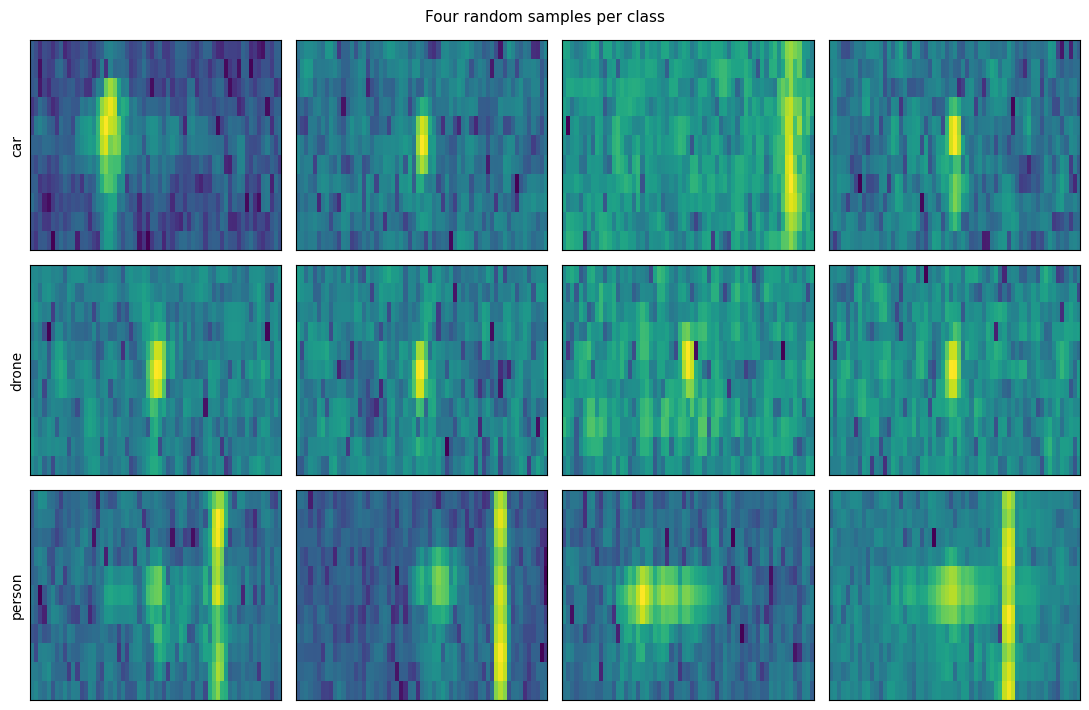

In [ ]:
import matplotlib.pyplot as plt

X, y = d['X'], d['y']
classes = sorted(set(y.tolist()))
fig, axes = plt.subplots(len(classes), 4, figsize=(11, 2.4 * len(classes)))
rng = np.random.default_rng(0)
for r, c in enumerate(classes):
    idx = np.where(y == c)[0]
    for k, j in enumerate(rng.choice(idx, 4, replace=False)):
        ax = axes[r, k]
        ax.imshow(X[j], aspect='auto', cmap='viridis')
        ax.set_xticks([]); ax.set_yticks([])
        if k == 0:
            ax.set_ylabel(c, fontsize=10)
plt.suptitle('Four random samples per class', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(DIRS['figures'], 'samples_per_class.png'), dpi=150)
plt.show()

---

# Step 2 — Model, published-structure check, split comparison

Two questions, in order.

**Q1. Does a compact CNN on RDRD reproduce the published error structure?**
Specifically: is drone *precision* below drone *recall*, and is
vehicle-called-drone the dominant confusion? The whole framing rests on that
structure. If our model does not show it, the framing needs revisiting before
any compression experiment runs. **This is the gate.**

**Q2. How much accuracy is lost moving from a random split to a grouped
split?** The Step 1 screen said the gap should be small, but a network can
exploit cues that a correlation screen cannot see. This is the measurement
that settles it.

Switch the runtime to **GPU** now: Runtime → Change runtime type → T4.

## 11. Write the Step 2 module

In [ ]:
%%writefile /content/src/step2.py
"""
Step 2: build the model dataset, train the compact CNN, reproduce the
published error structure, and compare grouped against random splitting.

Two questions this answers, in order:

  Q1  Does a compact CNN on RDRD reproduce the published error structure?
      Specifically: is drone PRECISION below drone RECALL, and is
      vehicle-called-drone the dominant confusion? If not, the framing
      built on that structure needs revisiting before anything else.

  Q2  How much accuracy is lost moving from a random split to a
      unit-grouped split? The similarity screen in Step 1 said the gap
      should be small. A network can exploit cues that screen cannot see,
      so this is the measurement that decides it.

Usage:
    python step2.py build   --root RAW --splits DIR --out DIR
    python step2.py train   --data DIR/dataset.npz --split grouped --seed 0
    python step2.py compare --data DIR/dataset.npz --seeds 0 1 2 3 4
"""

import argparse
import json
import os
import sys
from collections import Counter, defaultdict

import numpy as np

sys.path.insert(0, os.path.dirname(os.path.abspath(__file__)))
import rdrd

CLASSES = ["car", "drone", "person"]
VAL_FRAC = 0.15


# ----------------------------------------------------------------- build

def build(args):
    grouped = json.load(open(os.path.join(args.splits, "split_grouped.json")))
    randomd = json.load(open(os.path.join(args.splits, "split_random.json")))

    side_g, side_r = {}, {}
    for tag, sp in (("train", grouped["train"]), ("test", grouped["test"])):
        for p in sp:
            side_g[p] = tag
    for tag, sp in (("train", randomd["train"]), ("test", randomd["test"])):
        for p in sp:
            side_r[p] = tag

    paths = sorted(side_g)
    print("loading %d samples..." % len(paths))
    X, y, unit, keep = [], [], [], []
    for i, p in enumerate(paths):
        try:
            m = rdrd.load_matrix(p)
        except ValueError:
            continue
        lab = None
        for part in p.split(os.sep):
            g = rdrd.class_of(part)
            if g:
                lab = g
        if lab is None:
            continue
        X.append(m)
        y.append(lab)
        unit.append(lab + "/" + rdrd.timestamp_of(os.path.dirname(p)))
        keep.append(p)
        if (i + 1) % 4000 == 0:
            print("  %d" % (i + 1))

    shapes = Counter(m.shape for m in X)
    dom = shapes.most_common(1)[0][0]
    sel = [i for i, m in enumerate(X) if m.shape == dom]
    print("shapes %s -> keeping %d" % (dict(shapes), len(sel)))

    X = np.stack([X[i] for i in sel]).astype(np.float32)
    y = np.array([y[i] for i in sel])
    unit = np.array([unit[i] for i in sel])
    keep = [keep[i] for i in sel]

    # grouped: carve a validation set out of TRAIN UNITS, never train frames
    rng = np.random.default_rng(12345)
    grp = np.array([side_g[p] for p in keep], dtype=object)
    for c in CLASSES:
        tr_units = sorted({unit[i] for i in range(len(keep))
                           if y[i] == c and grp[i] == "train"})
        rng.shuffle(tr_units)
        n_val = max(1, int(round(VAL_FRAC * len(tr_units))))
        val_units = set(tr_units[:n_val])
        for i in range(len(keep)):
            if grp[i] == "train" and unit[i] in val_units:
                grp[i] = "val"

    rnd = np.array([side_r[p] for p in keep], dtype=object)
    idx = np.where(rnd == "train")[0]
    rng.shuffle(idx)
    rnd[idx[:int(round(VAL_FRAC * len(idx)))]] = "val"

    os.makedirs(args.out, exist_ok=True)
    out = os.path.join(args.out, "dataset.npz")
    np.savez_compressed(out, X=X, y=y, unit=unit,
                        grouped=grp.astype(str), random=rnd.astype(str),
                        path=np.array(keep))
    print("\nwritten %s   X=%s" % (out, X.shape))
    for name, arr in (("grouped", grp), ("random", rnd)):
        print("  %-8s %s" % (name, dict(Counter(arr.tolist()))))
    print("  classes %s" % dict(Counter(y.tolist())))
    # sanity: no unit may span grouped train/val/test
    span = 0
    for u in set(unit.tolist()):
        s = {grp[i] for i in range(len(unit)) if unit[i] == u}
        if len(s) > 1:
            span += 1
    print("  units spanning grouped subsets: %d (must be 0)" % span)


# ----------------------------------------------------------------- model

def make_model(torch, nn, widths=(64, 128, 208, 288), n_class=3):
    """
    Compact depthwise-separable CNN, ~101k parameters.

    Sized to match the published RangeDopplerNet Type-2 reference on this
    dataset (101,419 parameters) so that its compression behaviour is
    representative of a model someone would actually deploy. A reviewer
    will ask why this architecture stands in for deployed models; matching
    the reference size is the answer.
    """
    class Sep(nn.Module):
        def __init__(self, cin, cout, stride):
            super().__init__()
            self.dw = nn.Conv2d(cin, cin, 3, stride, 1, groups=cin, bias=False)
            self.pw = nn.Conv2d(cin, cout, 1, bias=False)
            self.bn = nn.BatchNorm2d(cout)
        def forward(self, x):
            return nn.functional.relu(self.bn(self.pw(self.dw(x))))

    class Net(nn.Module):
        def __init__(self):
            super().__init__()
            w = widths
            self.stem = nn.Sequential(
                nn.Conv2d(1, w[0], 3, 1, 1, bias=False),
                nn.BatchNorm2d(w[0]), nn.ReLU(inplace=True))
            self.b1 = Sep(w[0], w[1], (1, 2))
            self.b2 = Sep(w[1], w[2], (2, 2))
            self.b3 = Sep(w[2], w[3], (1, 2))
            self.head = nn.Linear(w[3], n_class)
            self.drop = nn.Dropout(0.2)
        def forward(self, x):
            x = self.b3(self.b2(self.b1(self.stem(x))))
            x = x.mean(dim=(2, 3))
            return self.head(self.drop(x))
    return Net()


def normalise(X):
    """Peak-referenced: peak becomes 0 dB, scaled by 60 dB of headroom."""
    peak = X.reshape(len(X), -1).max(axis=1)[:, None, None]
    return ((X - peak) / 60.0).astype(np.float32)


# ----------------------------------------------------------------- train

def run_training(data, split, seed, epochs=40, bs=128, lr=3e-3, quiet=False):
    import torch
    import torch.nn as nn

    torch.manual_seed(seed)
    np.random.seed(seed)
    dev = "cuda" if torch.cuda.is_available() else "cpu"

    X = normalise(data["X"])
    y = data["y"]
    sub = data[split]
    cls_idx = {c: i for i, c in enumerate(CLASSES)}
    yi = np.array([cls_idx[c] for c in y])

    def tensors(tag):
        m = sub == tag
        return (torch.tensor(X[m]).unsqueeze(1), torch.tensor(yi[m]))

    Xtr, ytr = tensors("train")
    Xva, yva = tensors("val")
    Xte, yte = tensors("test")

    model = make_model(torch, nn).to(dev)
    n_par = sum(p.numel() for p in model.parameters())
    if not quiet:
        print("  device %s | params %d | train %d val %d test %d"
              % (dev, n_par, len(Xtr), len(Xva), len(Xte)))

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.OneCycleLR(
        opt, max_lr=lr, total_steps=epochs * max(1, len(Xtr) // bs + 1))
    lossf = nn.CrossEntropyLoss()

    best, best_state, bad = -1.0, None, 0
    for ep in range(epochs):
        model.train()
        perm = torch.randperm(len(Xtr))
        for i in range(0, len(perm), bs):
            j = perm[i:i + bs]
            xb, yb = Xtr[j].to(dev), ytr[j].to(dev)
            opt.zero_grad()
            loss = lossf(model(xb), yb)
            loss.backward()
            opt.step()
            try:
                sched.step()
            except Exception:
                pass
        model.eval()
        with torch.no_grad():
            pv = []
            for i in range(0, len(Xva), 512):
                pv.append(model(Xva[i:i + 512].to(dev)).argmax(1).cpu())
            acc = (torch.cat(pv) == yva).float().mean().item() if len(Xva) else 0.0
        if acc > best:
            best, bad = acc, 0
            best_state = {k: v.detach().cpu().clone()
                          for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= 10:
                break
    if best_state:
        model.load_state_dict(best_state)

    model.eval()
    with torch.no_grad():
        pt = []
        for i in range(0, len(Xte), 512):
            pt.append(model(Xte[i:i + 512].to(dev)).argmax(1).cpu())
        pred = torch.cat(pt).numpy()
    true = yte.numpy()

    cm = np.zeros((3, 3), dtype=int)
    for t, p in zip(true, pred):
        cm[t, p] += 1
    per = {}
    for i, c in enumerate(CLASSES):
        tp = cm[i, i]
        rec = tp / max(1, cm[i].sum())
        pre = tp / max(1, cm[:, i].sum())
        per[c] = {"recall": float(rec), "precision": float(pre),
                  "f1": float(2 * rec * pre / max(1e-9, rec + pre))}
    return {"accuracy": float((pred == true).mean()), "per_class": per,
            "confusion": cm.tolist(), "val_acc": float(best),
            "params": int(n_par)}


def print_result(name, r):
    print("\n  %s   accuracy %.4f  (val %.4f, %d params)"
          % (name, r["accuracy"], r["val_acc"], r["params"]))
    print("    %-8s %9s %10s %8s" % ("class", "recall", "precision", "F1"))
    for c in CLASSES:
        p = r["per_class"][c]
        print("    %-8s %9.4f %10.4f %8.4f"
              % (c, p["recall"], p["precision"], p["f1"]))
    cm = np.array(r["confusion"])
    print("    confusion (rows true, cols predicted): %s" % CLASSES)
    for i, c in enumerate(CLASSES):
        print("      %-8s %s" % (c, "  ".join("%6d" % v for v in cm[i])))


def check_structure(r):
    """Does this reproduce the published error structure?"""
    d = r["per_class"]["drone"]
    cm = np.array(r["confusion"])
    ci, di = CLASSES.index("car"), CLASSES.index("drone")
    car_to_drone, drone_to_car = int(cm[ci, di]), int(cm[di, ci])
    f1s = {c: r["per_class"][c]["f1"] for c in CLASSES}
    weakest = min(f1s, key=f1s.get)
    print("\n  Published-structure check")
    print("    drone precision below drone recall : %s  (%.4f vs %.4f)"
          % (d["precision"] < d["recall"], d["precision"], d["recall"]))
    print("    car->drone exceeds drone->car      : %s  (%d vs %d)"
          % (car_to_drone > drone_to_car, car_to_drone, drone_to_car))
    print("    weakest class by F1                : %s" % weakest)
    return {"drone_prec_below_rec": bool(d["precision"] < d["recall"]),
            "car_to_drone": car_to_drone, "drone_to_car": drone_to_car,
            "weakest_f1": weakest}


# ----------------------------------------------------------------- main

def main():
    ap = argparse.ArgumentParser()
    sub = ap.add_subparsers(dest="cmd", required=True)

    b = sub.add_parser("build")
    b.add_argument("--splits", required=True)
    b.add_argument("--out", required=True)

    t = sub.add_parser("train")
    t.add_argument("--data", required=True)
    t.add_argument("--split", default="grouped", choices=["grouped", "random"])
    t.add_argument("--seed", type=int, default=0)
    t.add_argument("--epochs", type=int, default=40)

    c = sub.add_parser("compare")
    c.add_argument("--data", required=True)
    c.add_argument("--seeds", type=int, nargs="+", default=[0, 1, 2])
    c.add_argument("--epochs", type=int, default=40)
    c.add_argument("--out", default=None)

    args = ap.parse_args()

    if args.cmd == "build":
        build(args)
        return

    data = np.load(args.data, allow_pickle=False)

    if args.cmd == "train":
        r = run_training(data, args.split, args.seed, args.epochs)
        print_result("%s split, seed %d" % (args.split, args.seed), r)
        check_structure(r)
        return

    # compare
    res = defaultdict(list)
    for split in ("random", "grouped"):
        for s in args.seeds:
            print("\n[%s split, seed %d]" % (split, s))
            r = run_training(data, split, s, args.epochs, quiet=(s != args.seeds[0]))
            res[split].append(r)
            print("    acc %.4f  drone F1 %.4f"
                  % (r["accuracy"], r["per_class"]["drone"]["f1"]))

    print("\n" + "=" * 66)
    print("SPLIT COMPARISON  (mean +/- sd over %d seeds)" % len(args.seeds))
    print("=" * 66)
    print("  %-9s %16s %16s %16s"
          % ("split", "accuracy", "drone F1", "drone precision"))
    summ = {}
    for split in ("random", "grouped"):
        a = np.array([r["accuracy"] for r in res[split]])
        f = np.array([r["per_class"]["drone"]["f1"] for r in res[split]])
        p = np.array([r["per_class"]["drone"]["precision"] for r in res[split]])
        summ[split] = {"acc": [float(a.mean()), float(a.std())],
                       "drone_f1": [float(f.mean()), float(f.std())],
                       "drone_prec": [float(p.mean()), float(p.std())]}
        print("  %-9s %8.4f +/-%.4f %8.4f +/-%.4f %8.4f +/-%.4f"
              % (split, a.mean(), a.std(), f.mean(), f.std(), p.mean(), p.std()))
    drop = summ["random"]["acc"][0] - summ["grouped"]["acc"][0]
    print("\n  accuracy lost moving to grouped splitting: %+.4f" % (-drop))
    if drop > 0.03:
        print("  A real leakage effect the Step 1 screen did not detect.")
    else:
        print("  Consistent with the Step 1 screen: little leakage on RDRD.")

    print_result("grouped, seed %d" % args.seeds[0], res["grouped"][0])
    st = check_structure(res["grouped"][0])

    if args.out:
        json.dump({"summary": summ, "structure": st,
                   "runs": {k: v for k, v in res.items()}},
                  open(args.out, "w"), indent=2)
        print("\n  written %s" % args.out)


if __name__ == "__main__":
    main()


Writing /content/src/step2.py


In [ ]:
shutil.copy('/content/src/step2.py', os.path.join(DIRS['src'], 'step2.py'))

import torch
print('torch', torch.__version__, '| cuda', torch.cuda.is_available())
if not torch.cuda.is_available():
    print('NOTE: no GPU. It will still run, just slower.')

torch 2.11.0+cu128 | cuda True


## 12. Build the model dataset

Joins the frozen splits to the sample arrays and carves a validation set.

The validation set is taken from whole **training units**, never from
training frames. Using random frames for validation on a grouped split would
leak the very thing the split exists to prevent, and the early-stopping
choice would be made on contaminated data. The build asserts that no unit
spans train, val and test.

In [ ]:
DATA_DIR = os.path.join(PROJECT, 'cache')
proc = subprocess.run(
    [sys.executable, 'step2.py', 'build',
     '--splits', DIRS['splits'], '--out', DATA_DIR],
    cwd=LOCAL_SRC, capture_output=True, text=True)
print(proc.stdout[-2500:])
if proc.returncode:
    print(proc.stderr[-3000:])

loading 17485 samples...
  4000
  8000
  12000
  16000
shapes {(11, 61): 17485} -> keeping 17485

written /content/drive/MyDrive/radar_compression/cache/dataset.npz   X=(17485, 11, 61)
  grouped  {'test': 4926, 'train': 9921, 'val': 2638}
  random   {'test': 5246, 'train': 10403, 'val': 1836}
  classes {'car': 5720, 'drone': 5065, 'person': 6700}
  units spanning grouped subsets: 0 (must be 0)



## 13. The gate: one grouped run

Look at the published-structure check at the bottom. The reference model on
this dataset reported drone recall 96.55% with drone precision 93.33%, and
64 vehicles called drone against 30 the other way.

In [ ]:
proc = subprocess.run(
    [sys.executable, 'step2.py', 'train',
     '--data', os.path.join(DATA_DIR, 'dataset.npz'),
     '--split', 'grouped', '--seed', '0', '--epochs', '40'],
    cwd=LOCAL_SRC, capture_output=True, text=True)
print(proc.stdout)
if proc.returncode:
    print(proc.stderr[-3000:])

  device cuda | params 101139 | train 9921 val 2638 test 4926

  grouped split, seed 0   accuracy 0.9336  (val 0.9215, 101139 params)
    class       recall  precision       F1
    car         0.9038     0.9122   0.9080
    drone       0.8718     0.8648   0.8683
    person      0.9868     0.9841   0.9855
    confusion (rows true, cols predicted): ['car', 'drone', 'person']
      car        1465     130      26
      drone       133     966       9
      person        8      21    2168

  Published-structure check
    drone precision below drone recall : True  (0.8648 vs 0.8718)
    car->drone exceeds drone->car      : False  (130 vs 133)
    weakest class by F1                : drone



## 14. Split comparison

Five seeds on each split. Roughly 10 to 25 minutes on a T4.

In [ ]:
proc = subprocess.run(
    [sys.executable, 'step2.py', 'compare',
     '--data', os.path.join(DATA_DIR, 'dataset.npz'),
     '--seeds', '0', '1', '2', '3', '4', '--epochs', '40',
     '--out', os.path.join(DIRS['reports'], 'step2_compare.json')],
    cwd=LOCAL_SRC, capture_output=True, text=True)
print(proc.stdout[-6000:])
if proc.returncode:
    print(proc.stderr[-3000:])


[random split, seed 0]
  device cuda | params 101139 | train 10403 val 1836 test 5246
    acc 0.9279  drone F1 0.8963

[random split, seed 1]
    acc 0.9319  drone F1 0.8966

[random split, seed 2]
    acc 0.9222  drone F1 0.8894

[random split, seed 3]
    acc 0.9333  drone F1 0.8944

[random split, seed 4]
    acc 0.9377  drone F1 0.9033

[grouped split, seed 0]
  device cuda | params 101139 | train 9921 val 2638 test 4926
    acc 0.9204  drone F1 0.8465

[grouped split, seed 1]
    acc 0.9206  drone F1 0.8684

[grouped split, seed 2]
    acc 0.9409  drone F1 0.8946

[grouped split, seed 3]
    acc 0.9365  drone F1 0.8853

[grouped split, seed 4]
    acc 0.9344  drone F1 0.8803

SPLIT COMPARISON  (mean +/- sd over 5 seeds)
  split             accuracy         drone F1  drone precision
  random      0.9306 +/-0.0052   0.8960 +/-0.0045   0.8775 +/-0.0076
  grouped     0.9306 +/-0.0085   0.8750 +/-0.0166   0.8467 +/-0.0113

  accuracy lost moving to grouped splitting: -0.0000
  Consist

## What to send back

1. Cell 13 — the full per-class table, the confusion matrix, and the
   three lines of the published-structure check.
2. Cell 14 — the split comparison summary.

**How to read the gate.** If drone precision sits below drone recall and
car-to-drone exceeds drone-to-car, the framing holds and we go straight to
the compression grid. If it does not, stop: the discrepancy with the
published baseline becomes the thing to understand first, and it is much
cheaper to deal with now than after a grid of experiments is built on top
of it.

Accuracy near 100% would mean the mock-like separability problem is real on
this data too, and we would need the harder-task variant sooner than
planned.

---

# Step 2b — Grouped k-fold and normalisation ablation

Step 2 left two things unsettled, and both must close before the compression
grid is built on top of them.

**The five seeds varied initialisation, not partition.** The grouped split
was one fixed partition, so the 2.1-point drone F1 drop could equally be an
accident of which units landed in test. With 21 drone units and about six
held out, that is a live risk. Grouped k-fold rotates the held-out units and
separates split variance from seed variance.

**The baseline sits about 5 points below the published 98%.** One suspect is
peak-referenced normalisation. It preserves the headroom structure the
mechanism depends on but discards absolute return level, which is a strong
class cue given person 43.5, car 34.7 and drone 27.3 dB.

Note this changes protocol: k-fold supersedes the single grouped split for
measuring leakage. Nothing has been reported yet, and k-fold is strictly the
better instrument, so this is a correction rather than a second bite.

## 15. Write the Step 2b module

In [ ]:
%%writefile /content/src/step2b.py
"""
Step 2b: grouped k-fold and normalisation ablation.

Two gaps in Step 2 that must close before the compression grid.

  1. Five seeds varied the INITIALISATION, not the partition. The grouped
     split was a single fixed partition, so a 2.1-point drone F1 drop could
     equally be an accident of which units landed in test. With 21 drone
     units and about 6 held out, that is a live risk. Grouped k-fold rotates
     the held-out units and separates split variance from seed variance.

  2. The baseline sits ~5 points below the published 98%. One suspect is
     peak-referenced normalisation: it preserves the headroom structure the
     mechanism depends on, but discards absolute return level, which is a
     strong class cue given person 43.5 / car 34.7 / drone 27.3 dB. That
     trade may be correct for this study, but it should be measured.

Usage:
    python step2b.py kfold --data DIR/dataset.npz --folds 5 --seeds 0 1 2
    python step2b.py norm  --data DIR/dataset.npz --folds 5
"""

import argparse
import json
import os
import sys
from collections import defaultdict

import numpy as np

sys.path.insert(0, os.path.dirname(os.path.abspath(__file__)))
from step2 import CLASSES, make_model

VAL_FRAC = 0.15

# two-tailed t critical values at p=0.05, indexed by degrees of freedom
T_CRIT = {1: 12.71, 2: 4.30, 3: 3.18, 4: 2.78, 5: 2.57, 6: 2.45,
          7: 2.36, 8: 2.31, 9: 2.26, 10: 2.23}


# ------------------------------------------------------------ normalisation

def normalise(X, scheme):
    """
    peak       peak -> 0 dB, scaled by 60 dB. Keeps headroom shape,
               DISCARDS absolute return level.
    offset     fixed shift only. Keeps absolute level.
    global     standardised by global mean/sd. Keeps absolute level.
    peak_level two channels: peak-referenced, plus a constant plane holding
               the peak itself. Keeps headroom shape AND absolute level.
    """
    X = X.astype(np.float32)
    peak = X.reshape(len(X), -1).max(axis=1)[:, None, None]
    if scheme == "peak":
        return ((X - peak) / 60.0)[:, None]
    if scheme == "offset":
        return ((X + 60.0) / 60.0)[:, None]
    if scheme == "global":
        return ((X - X.mean()) / (X.std() + 1e-6))[:, None]
    if scheme == "peak_level":
        a = (X - peak) / 60.0
        b = np.broadcast_to((peak + 60.0) / 60.0, X.shape).astype(np.float32)
        return np.stack([a, b], axis=1)
    raise ValueError(scheme)


# ------------------------------------------------------------------ folds

def make_grouped_folds(y, unit, k, seed=777):
    """
    Assign each class's UNITS to k folds, balancing sample counts rather
    than unit counts, since unit sizes vary from 31 to 660 files.
    """
    rng = np.random.default_rng(seed)
    fold = np.full(len(y), -1, dtype=int)
    for c in CLASSES:
        us = sorted({unit[i] for i in range(len(y)) if y[i] == c})
        sizes = {u: int(np.sum((unit == u))) for u in us}
        order = sorted(us, key=lambda u: -sizes[u])
        load = np.zeros(k, dtype=int)
        assign = {}
        for u in order:
            f = int(np.argmin(load))       # greedy: fill the emptiest fold
            assign[u] = f
            load[f] += sizes[u]
        for i in range(len(y)):
            if y[i] == c:
                fold[i] = assign[unit[i]]
        rng.random()
    return fold


def make_random_folds(y, k, sizes_per_fold, seed=777):
    """Frame-level folds matched in size to the grouped folds, per class."""
    rng = np.random.default_rng(seed)
    fold = np.full(len(y), -1, dtype=int)
    for c in CLASSES:
        idx = np.where(y == c)[0]
        rng.shuffle(idx)
        pos = 0
        for f in range(k):
            n = sizes_per_fold[c][f]
            fold[idx[pos:pos + n]] = f
            pos += n
        fold[idx[pos:]] = k - 1
    return fold


def split_for_fold(fold, f, k, y, unit, grouped, seed):
    """test = fold f; val carved from the remaining folds (units if grouped)."""
    rng = np.random.default_rng(1000 + seed)
    test = fold == f
    pool = ~test
    val = np.zeros(len(y), dtype=bool)
    if grouped:
        for c in CLASSES:
            us = sorted({unit[i] for i in range(len(y)) if pool[i] and y[i] == c})
            rng.shuffle(us)
            n = max(1, int(round(VAL_FRAC * len(us))))
            chosen = set(us[:n])
            for i in range(len(y)):
                if pool[i] and y[i] == c and unit[i] in chosen:
                    val[i] = True
    else:
        idx = np.where(pool)[0]
        rng.shuffle(idx)
        val[idx[:int(round(VAL_FRAC * len(idx)))]] = True
    train = pool & ~val
    return train, val, test


# ------------------------------------------------------------------ train

def train_once(Xn, yi, train, val, test, seed, epochs=40, bs=128, lr=3e-3):
    import torch
    import torch.nn as nn
    torch.manual_seed(seed)
    np.random.seed(seed)
    dev = "cuda" if torch.cuda.is_available() else "cpu"

    Xtr = torch.tensor(Xn[train]); ytr = torch.tensor(yi[train])
    Xva = torch.tensor(Xn[val]);   yva = torch.tensor(yi[val])
    Xte = torch.tensor(Xn[test]);  yte = torch.tensor(yi[test])

    model = make_model(torch, nn).to(dev)
    if Xn.shape[1] != 1:                      # widen the stem for 2 channels
        old = model.stem[0]
        model.stem[0] = nn.Conv2d(Xn.shape[1], old.out_channels, 3, 1, 1,
                                  bias=False).to(dev)

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.OneCycleLR(
        opt, max_lr=lr, total_steps=epochs * max(1, len(Xtr) // bs + 1))
    lossf = nn.CrossEntropyLoss()

    best, best_state, bad = -1.0, None, 0
    for _ep in range(epochs):
        model.train()
        perm = torch.randperm(len(Xtr))
        for i in range(0, len(perm), bs):
            j = perm[i:i + bs]
            opt.zero_grad()
            lossf(model(Xtr[j].to(dev)), ytr[j].to(dev)).backward()
            opt.step()
            try:
                sched.step()
            except Exception:
                pass
        model.eval()
        with torch.no_grad():
            pv = [model(Xva[i:i + 512].to(dev)).argmax(1).cpu()
                  for i in range(0, len(Xva), 512)]
            acc = (torch.cat(pv) == yva).float().mean().item()
        if acc > best:
            best, bad = acc, 0
            best_state = {k: v.detach().cpu().clone()
                          for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= 10:
                break
    model.load_state_dict(best_state)

    model.eval()
    with torch.no_grad():
        pt = [model(Xte[i:i + 512].to(dev)).argmax(1).cpu()
              for i in range(0, len(Xte), 512)]
        pred = torch.cat(pt).numpy()
    true = yte.numpy()

    cm = np.zeros((3, 3), dtype=int)
    for t, p in zip(true, pred):
        cm[t, p] += 1
    out = {"accuracy": float((pred == true).mean()), "confusion": cm.tolist()}
    for i, c in enumerate(CLASSES):
        rec = cm[i, i] / max(1, cm[i].sum())
        pre = cm[i, i] / max(1, cm[:, i].sum())
        out[c] = {"recall": float(rec), "precision": float(pre),
                  "f1": float(2 * rec * pre / max(1e-9, rec + pre))}
    return out


# ------------------------------------------------------------------ stats

def decompose(runs, metric):
    """Separate between-fold (split) variance from within-fold (seed) variance."""
    by_fold = defaultdict(list)
    for r in runs:
        by_fold[r["fold"]].append(r["result"][metric] if metric == "accuracy"
                                  else r["result"][metric[0]][metric[1]])
    fold_means = np.array([np.mean(v) for _f, v in sorted(by_fold.items())])
    within = np.array([np.std(v, ddof=1) if len(v) > 1 else 0.0
                       for _f, v in sorted(by_fold.items())])
    return {"mean": float(fold_means.mean()),
            "between_fold_sd": float(fold_means.std(ddof=1)) if len(fold_means) > 1 else 0.0,
            "within_fold_sd": float(within.mean()),
            "fold_means": [float(x) for x in fold_means]}


def paired(g_runs, r_runs, metric):
    """Per-fold paired difference, grouped minus random."""
    def fold_means(runs):
        d = defaultdict(list)
        for r in runs:
            d[r["fold"]].append(r["result"][metric] if metric == "accuracy"
                                else r["result"][metric[0]][metric[1]])
        return np.array([np.mean(v) for _f, v in sorted(d.items())])
    g, r = fold_means(g_runs), fold_means(r_runs)
    d = g - r
    sd = d.std(ddof=1) if len(d) > 1 else 0.0
    t = float(d.mean() / (sd / np.sqrt(len(d)))) if sd > 0 else float("nan")
    return {"diffs": [float(x) for x in d], "mean_diff": float(d.mean()),
            "sd": float(sd), "t": t, "n": int(len(d))}


def label(metric):
    return metric if isinstance(metric, str) else "%s %s" % metric


# ------------------------------------------------------------------ main

def main():
    ap = argparse.ArgumentParser()
    sub = ap.add_subparsers(dest="cmd", required=True)
    for name in ("kfold", "norm"):
        p = sub.add_parser(name)
        p.add_argument("--data", required=True)
        p.add_argument("--folds", type=int, default=5)
        p.add_argument("--epochs", type=int, default=40)
        p.add_argument("--out", default=None)
        if name == "kfold":
            p.add_argument("--seeds", type=int, nargs="+", default=[0, 1, 2])
            p.add_argument("--scheme", default="peak")
        else:
            p.add_argument("--seed", type=int, default=0)
            p.add_argument("--schemes", nargs="+",
                           default=["peak", "offset", "global", "peak_level"])
    args = ap.parse_args()

    d = np.load(args.data, allow_pickle=False)
    X, y, unit = d["X"], d["y"], d["unit"]
    cls_idx = {c: i for i, c in enumerate(CLASSES)}
    yi = np.array([cls_idx[c] for c in y])
    k = args.folds

    gfold = make_grouped_folds(y, unit, k)
    sizes = {c: [int(np.sum((y == c) & (gfold == f))) for f in range(k)]
             for c in CLASSES}
    rfold = make_random_folds(y, k, sizes)

    print("=" * 70)
    print("fold sizes per class (grouped)")
    for c in CLASSES:
        print("  %-8s %s" % (c, sizes[c]))
    print("=" * 70)

    if args.cmd == "kfold":
        Xn = normalise(X, args.scheme)
        allruns = {}
        for gname, fold, grouped in (("grouped", gfold, True),
                                     ("random", rfold, False)):
            runs = []
            for f in range(k):
                for s in args.seeds:
                    tr, va, te = split_for_fold(fold, f, k, y, unit, grouped, s)
                    r = train_once(Xn, yi, tr, va, te, s, args.epochs)
                    runs.append({"fold": f, "seed": s, "result": r})
                    print("  %-8s fold %d seed %d   acc %.4f  drone F1 %.4f"
                          % (gname, f, s, r["accuracy"], r["drone"]["f1"]))
            allruns[gname] = runs

        print("\n" + "=" * 70)
        print("VARIANCE DECOMPOSITION  (%d folds x %d seeds)"
              % (k, len(args.seeds)))
        print("=" * 70)
        metrics = ["accuracy", ("drone", "f1"), ("drone", "precision"),
                   ("drone", "recall"), ("car", "f1")]
        print("  %-18s %-9s %8s %12s %12s"
              % ("metric", "split", "mean", "fold sd", "seed sd"))
        summary = {}
        for m in metrics:
            for gname in ("random", "grouped"):
                st = decompose(allruns[gname], m)
                summary.setdefault(label(m), {})[gname] = st
                print("  %-18s %-9s %8.4f %12.4f %12.4f"
                      % (label(m), gname, st["mean"],
                         st["between_fold_sd"], st["within_fold_sd"]))

        print("\n" + "=" * 70)
        print("PAIRED PER-FOLD DIFFERENCE  (grouped minus random)")
        print("=" * 70)
        print("  %-18s %10s %10s %8s   %s"
              % ("metric", "mean diff", "sd", "t", "per fold"))
        pairs = {}
        for m in metrics:
            pr = paired(allruns["grouped"], allruns["random"], m)
            pairs[label(m)] = pr
            print("  %-18s %+10.4f %10.4f %8.2f   %s"
                  % (label(m), pr["mean_diff"], pr["sd"], pr["t"],
                     " ".join("%+.3f" % x for x in pr["diffs"])))

        print("")
        acc = pairs["accuracy"]
        dr = pairs["drone f1"]
        tc = T_CRIT.get(k - 1, 2.0)
        print("  With %d folds (df=%d), |t| above %.2f is significant at the"
              % (k, k - 1, tc))
        print("  5 percent level. Compare the aggregate accuracy row against")
        print("  the drone rows: if accuracy is flat while drone F1 drops, the")
        print("  leakage is concentrated in one class and the headline number")
        print("  conceals it.")
        for nm, pr in (("accuracy", acc), ("drone F1", dr)):
            verdict = ("significant" if abs(pr["t"]) > tc else "not significant")
            print("    %-10s %+.4f  t=%6.2f  %s"
                  % (nm, pr["mean_diff"], pr["t"], verdict))

        if args.out:
            json.dump({"summary": summary, "paired": pairs,
                       "fold_sizes": sizes}, open(args.out, "w"), indent=2)
            print("\n  written %s" % args.out)
        return

    # ---------------------------------------------------------- norm
    print("\nNORMALISATION ABLATION (grouped folds, seed %d)" % args.seed)
    res = {}
    for scheme in args.schemes:
        Xn = normalise(X, scheme)
        runs = []
        for f in range(k):
            tr, va, te = split_for_fold(gfold, f, k, y, unit, True, args.seed)
            r = train_once(Xn, yi, tr, va, te, args.seed, args.epochs)
            runs.append({"fold": f, "seed": args.seed, "result": r})
            print("  %-11s (%dch) fold %d   acc %.4f  drone F1 %.4f"
                  % (scheme, Xn.shape[1], f, r["accuracy"], r["drone"]["f1"]))
        res[scheme] = runs

    print("\n" + "=" * 70)
    print("  %-12s %10s %10s %12s %12s"
          % ("scheme", "accuracy", "fold sd", "drone F1", "drone prec"))
    out = {}
    for scheme in args.schemes:
        a = decompose(res[scheme], "accuracy")
        f1 = decompose(res[scheme], ("drone", "f1"))
        pr = decompose(res[scheme], ("drone", "precision"))
        out[scheme] = {"accuracy": a, "drone_f1": f1, "drone_precision": pr}
        print("  %-12s %10.4f %10.4f %12.4f %12.4f"
              % (scheme, a["mean"], a["between_fold_sd"], f1["mean"], pr["mean"]))

    base = out.get("peak", {}).get("accuracy", {}).get("mean")
    best = max(out, key=lambda s: out[s]["accuracy"]["mean"])
    print("")
    if base is not None and out[best]["accuracy"]["mean"] - base > 0.01:
        print("  '%s' beats peak-referencing by %+.4f accuracy."
              % (best, out[best]["accuracy"]["mean"] - base))
        print("  Absolute return level is carrying real class information.")
        print("  Note the tension: that level is exactly what the headroom")
        print("  mechanism is about, so a scheme that hands the network the")
        print("  level directly may mask the effect the study wants to see.")
        print("  'peak_level' keeps both and is the compromise to prefer if")
        print("  it is the winner.")
    else:
        print("  No scheme beats peak-referencing by more than 1 point.")
        print("  The gap to the published 98 percent is not a normalisation")
        print("  artefact and needs another explanation.")

    if args.out:
        json.dump(out, open(args.out, "w"), indent=2)
        print("\n  written %s" % args.out)


if __name__ == "__main__":
    main()


Writing /content/src/step2b.py


In [ ]:
shutil.copy('/content/src/step2b.py', os.path.join(DIRS['src'], 'step2b.py'))
print('ok')

ok


## 16. Grouped k-fold

Five folds by three seeds, on each of the grouped and random protocols.
Roughly 30 to 60 minutes on a T4.

Folds are balanced by **sample count**, not unit count, because unit sizes
run from 31 to 660 files. Balancing units would give wildly uneven folds.

The output separates two sources of variation. `fold sd` is how much the
answer moves when you change which units are held out; `seed sd` is how much
it moves from initialisation alone. If `fold sd` dominates, the single-split
result from Step 2 was not trustworthy, which is the thing being tested.

In [ ]:
proc = subprocess.run(
    [sys.executable, 'step2b.py', 'kfold',
     '--data', os.path.join(DATA_DIR, 'dataset.npz'),
     '--folds', '5', '--seeds', '0', '1', '2', '--epochs', '40',
     '--out', os.path.join(DIRS['reports'], 'step2b_kfold.json')],
    cwd=LOCAL_SRC, capture_output=True, text=True)
print(proc.stdout[-7000:])
if proc.returncode:
    print(proc.stderr[-3000:])

fold sizes per class (grouped)
  car      [1039, 1088, 1231, 1207, 1155]
  drone    [1011, 1037, 1029, 992, 996]
  person   [1310, 1302, 1302, 1303, 1483]
  grouped  fold 0 seed 0   acc 0.9494  drone F1 0.9254
  grouped  fold 0 seed 1   acc 0.9432  drone F1 0.9155
  grouped  fold 0 seed 2   acc 0.9360  drone F1 0.9026
  grouped  fold 1 seed 0   acc 0.9093  drone F1 0.8644
  grouped  fold 1 seed 1   acc 0.9183  drone F1 0.8832
  grouped  fold 1 seed 2   acc 0.9157  drone F1 0.8757
  grouped  fold 2 seed 0   acc 0.9262  drone F1 0.8881
  grouped  fold 2 seed 1   acc 0.9354  drone F1 0.9079
  grouped  fold 2 seed 2   acc 0.9267  drone F1 0.9026
  grouped  fold 3 seed 0   acc 0.8284  drone F1 0.6596
  grouped  fold 3 seed 1   acc 0.8421  drone F1 0.7085
  grouped  fold 3 seed 2   acc 0.8370  drone F1 0.6794
  grouped  fold 4 seed 0   acc 0.9238  drone F1 0.8730
  grouped  fold 4 seed 1   acc 0.9359  drone F1 0.9036
  grouped  fold 4 seed 2   acc 0.9218  drone F1 0.8707
  random   fold 0 se

## 17. Normalisation ablation

Four schemes on the grouped folds:

| scheme | headroom shape | absolute level |
|---|---|---|
| `peak` (current) | kept | **discarded** |
| `offset` | kept | kept |
| `global` | kept | kept |
| `peak_level` | kept | kept, as a second channel |

There is a real tension here. Absolute return level almost certainly carries
class information, so handing it to the network should raise accuracy. But
that level is exactly what the headroom mechanism is about, so a scheme that
supplies it directly may mask the very effect the compression study wants to
observe. `peak_level` is the compromise: it keeps the headroom shape and
supplies the level separately, so the network can use it without the shape
being rescaled away.

Whichever wins, the choice gets stated in the paper with this table behind
it rather than asserted.

In [ ]:
proc = subprocess.run(
    [sys.executable, 'step2b.py', 'norm',
     '--data', os.path.join(DATA_DIR, 'dataset.npz'),
     '--folds', '5', '--epochs', '40', '--seed', '0',
     '--out', os.path.join(DIRS['reports'], 'step2b_norm.json')],
    cwd=LOCAL_SRC, capture_output=True, text=True)
print(proc.stdout[-5000:])
if proc.returncode:
    print(proc.stderr[-3000:])

fold sizes per class (grouped)
  car      [1039, 1088, 1231, 1207, 1155]
  drone    [1011, 1037, 1029, 992, 996]
  person   [1310, 1302, 1302, 1303, 1483]

NORMALISATION ABLATION (grouped folds, seed 0)
  peak        (1ch) fold 0   acc 0.9321  drone F1 0.8925
  peak        (1ch) fold 1   acc 0.9145  drone F1 0.8732
  peak        (1ch) fold 2   acc 0.9307  drone F1 0.8945
  peak        (1ch) fold 3   acc 0.8312  drone F1 0.6701
  peak        (1ch) fold 4   acc 0.9334  drone F1 0.8968
  offset      (1ch) fold 0   acc 0.9524  drone F1 0.9260
  offset      (1ch) fold 1   acc 0.9457  drone F1 0.9234
  offset      (1ch) fold 2   acc 0.9318  drone F1 0.9188
  offset      (1ch) fold 3   acc 0.8449  drone F1 0.7501
  offset      (1ch) fold 4   acc 0.9516  drone F1 0.9253
  global      (1ch) fold 0   acc 0.9313  drone F1 0.8878
  global      (1ch) fold 1   acc 0.9448  drone F1 0.9210
  global      (1ch) fold 2   acc 0.9419  drone F1 0.9160
  global      (1ch) fold 3   acc 0.8418  drone F1 0.6578

## What to send back

1. Cell 16 — the variance decomposition table and the paired difference
   table with the t values.
2. Cell 17 — the four-scheme comparison.

**How to read cell 16.** The question is not whether grouped scores lower.
It is whether the drone-class drop survives once split variance is properly
accounted for. If `fold sd` on drone F1 is comparable to the paired mean
difference, the Step 2 result was partition luck and the leakage claim goes
in the paper as a null. If the paired t exceeds the printed threshold while
aggregate accuracy stays flat, you have the concealment result on solid
statistical footing.

**How to read cell 17.** If `peak` is within about a point of the best
scheme, keep it and the 5-point gap to the published baseline needs a
different explanation. If `peak_level` wins clearly, switch to it before the
compression grid, since changing normalisation afterwards would invalidate
every grid result.

---

# Step 2c — Does session performance track session headroom?

Step 2b settled two things.

**The leakage claim is a null.** Paired t of -1.12 on drone F1. Four folds
sat at essentially zero difference and one fold produced -0.226. Leakage
would be spread across folds; a single catastrophic fold is something else.

**The variance asymmetry is the real finding.** Which drone sessions are
held out swings drone F1 by about +/-0.10; the same swing for cars is about
+/-0.01. On drone recall the fold-variance ratio between grouped and random
splitting is roughly 18x. The drone class does not generalise across
recording sessions and the car class largely does.

This asks whether signal level explains that. Session headroom runs from
16.1 dB (drone `12-41`) to 52.8 dB (drone `13-48`). If a session's recall
tracks its headroom, the mechanism the whole compression study rests on is
demonstrated on real data **before any bit is quantised** — which is a far
stronger form of the argument than the compression grid alone can provide.

Every unit sits in the test fold exactly once, so a single k-fold pass gives
an out-of-fold recall for every session at no extra cost.

Normalisation is now `offset`, per the Step 2b ablation.

## 18. Write the Step 2c module

In [ ]:
%%writefile /content/src/step2c.py
"""
Step 2c: does per-session performance track per-session headroom?

Step 2b found that which drone sessions are held out swings drone F1 by
about +/-0.10, while the same swing for cars is about +/-0.01 -- a variance
ratio near 18x on drone recall. The mean difference between grouped and
random splitting was NOT significant, so the leakage claim is a null. The
variance asymmetry is the real finding.

This asks the obvious next question: is that variance explained by signal
level? Session peak-to-floor ranges from 16.1 dB (drone 12-41) to 52.8 dB
(drone 13-48). If a session's recall tracks its headroom, the mechanism the
compression study rests on is demonstrated on real data BEFORE any bit is
quantised.

Method: run grouped k-fold. Every unit is in the test fold exactly once, so
one pass yields an out-of-fold recall for every session. Join that against
the session's measured headroom and correlate.

Usage:
    python step2c.py --data DIR/dataset.npz --folds 5 --seeds 0 1
"""

import argparse
import json
import os
import sys
from collections import defaultdict

import numpy as np

sys.path.insert(0, os.path.dirname(os.path.abspath(__file__)))
from step2 import CLASSES, make_model
from step2b import normalise, make_grouped_folds, split_for_fold


# ------------------------------------------------------------ headroom

def unit_headroom(X, unit):
    """Median peak-to-floor, in dB, per unit."""
    lin = 10.0 ** ((X - X.reshape(len(X), -1).max(axis=1)[:, None, None]) / 10.0)
    floor = np.median(lin.reshape(len(X), -1), axis=1)
    ptf = -10 * np.log10(np.maximum(floor, 1e-30))
    out = {}
    for u in sorted(set(unit.tolist())):
        m = unit == u
        out[u] = {"ptf_median": float(np.median(ptf[m])),
                  "ptf_p10": float(np.percentile(ptf[m], 10)),
                  "n": int(m.sum())}
    return out


# ------------------------------------------------------------ out-of-fold

def out_of_fold_predictions(Xn, yi, y, unit, gfold, k, seeds, epochs):
    """Every unit is tested exactly once per seed. Returns per-unit recall."""
    import torch
    import torch.nn as nn

    per_unit = defaultdict(list)
    dev = "cuda" if torch.cuda.is_available() else "cpu"

    for seed in seeds:
        for f in range(k):
            tr, va, te = split_for_fold(gfold, f, k, y, unit, True, seed)
            torch.manual_seed(seed)
            np.random.seed(seed)

            Xtr = torch.tensor(Xn[tr]); ytr = torch.tensor(yi[tr])
            Xva = torch.tensor(Xn[va]); yva = torch.tensor(yi[va])
            Xte = torch.tensor(Xn[te])

            model = make_model(torch, nn).to(dev)
            if Xn.shape[1] != 1:
                old = model.stem[0]
                model.stem[0] = nn.Conv2d(Xn.shape[1], old.out_channels,
                                          3, 1, 1, bias=False).to(dev)
            opt = torch.optim.AdamW(model.parameters(), lr=3e-3,
                                    weight_decay=1e-4)
            sched = torch.optim.lr_scheduler.OneCycleLR(
                opt, max_lr=3e-3, total_steps=epochs * max(1, len(Xtr) // 128 + 1))
            lossf = nn.CrossEntropyLoss()

            best, best_state, bad = -1.0, None, 0
            for _ep in range(epochs):
                model.train()
                perm = torch.randperm(len(Xtr))
                for i in range(0, len(perm), 128):
                    j = perm[i:i + 128]
                    opt.zero_grad()
                    lossf(model(Xtr[j].to(dev)), ytr[j].to(dev)).backward()
                    opt.step()
                    try:
                        sched.step()
                    except Exception:
                        pass
                model.eval()
                with torch.no_grad():
                    pv = [model(Xva[i:i + 512].to(dev)).argmax(1).cpu()
                          for i in range(0, len(Xva), 512)]
                    acc = (torch.cat(pv) == yva).float().mean().item()
                if acc > best:
                    best, bad = acc, 0
                    best_state = {kk: v.detach().cpu().clone()
                                  for kk, v in model.state_dict().items()}
                else:
                    bad += 1
                    if bad >= 10:
                        break
            model.load_state_dict(best_state)

            model.eval()
            with torch.no_grad():
                pt = [model(Xte[i:i + 512].to(dev)).argmax(1).cpu()
                      for i in range(0, len(Xte), 512)]
                pred = torch.cat(pt).numpy()
            idx = np.where(te)[0]
            for u in sorted(set(unit[idx].tolist())):
                m = unit[idx] == u
                per_unit[u].append(float((pred[m] == yi[idx][m]).mean()))
            print("    seed %d fold %d done" % (seed, f))
    return per_unit


# ------------------------------------------------------------ correlation

def pearson(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    if len(a) < 3 or a.std() == 0 or b.std() == 0:
        return float("nan")
    return float(((a - a.mean()) * (b - b.mean())).mean() / (a.std() * b.std()))


def spearman(a, b):
    def rank(v):
        o = np.argsort(np.argsort(np.asarray(v, float)))
        return o.astype(float)
    return pearson(rank(a), rank(b))


def t_from_r(r, n):
    if not np.isfinite(r) or n < 3 or abs(r) >= 1:
        return float("nan")
    return float(r * np.sqrt((n - 2) / (1 - r * r)))


# ------------------------------------------------------------------ main

def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--data", required=True)
    ap.add_argument("--folds", type=int, default=5)
    ap.add_argument("--seeds", type=int, nargs="+", default=[0, 1])
    ap.add_argument("--epochs", type=int, default=40)
    ap.add_argument("--scheme", default="offset")
    ap.add_argument("--out", default=None)
    args = ap.parse_args()

    d = np.load(args.data, allow_pickle=False)
    X, y, unit = d["X"], d["y"], d["unit"]
    cls_idx = {c: i for i, c in enumerate(CLASSES)}
    yi = np.array([cls_idx[c] for c in y])

    head = unit_headroom(X, unit)
    gfold = make_grouped_folds(y, unit, args.folds)
    Xn = normalise(X, args.scheme)

    print("running %d folds x %d seeds (scheme=%s)"
          % (args.folds, len(args.seeds), args.scheme))
    per_unit = out_of_fold_predictions(Xn, yi, y, unit, gfold,
                                       args.folds, args.seeds, args.epochs)

    print("\n" + "=" * 74)
    print("PER-SESSION RECALL vs HEADROOM")
    print("=" * 74)

    report = {}
    for c in CLASSES:
        rows = []
        for u in sorted(per_unit):
            if not u.startswith(c + "/"):
                continue
            rec = float(np.mean(per_unit[u]))
            sd = float(np.std(per_unit[u]))
            rows.append((u.split("/", 1)[1], head[u]["ptf_median"],
                         head[u]["ptf_p10"], head[u]["n"], rec, sd))
        if len(rows) < 3:
            continue
        rows.sort(key=lambda r: r[1])
        print("\n  %s  (%d sessions, sorted by headroom)" % (c.upper(), len(rows)))
        print("    %-10s %10s %10s %7s %9s %8s"
              % ("session", "ptf med", "ptf p10", "n", "recall", "sd"))
        for nm, pm, pp, n, rec, sd in rows:
            print("    %-10s %8.1f dB %8.1f dB %7d %9.4f %8.4f"
                  % (nm, pm, pp, n, rec, sd))

        ptf = [r[1] for r in rows]
        rec = [r[4] for r in rows]
        rp, rs = pearson(ptf, rec), spearman(ptf, rec)
        n = len(rows)
        print("    correlation of recall with headroom:")
        print("      Pearson  r = %+.3f  (t = %+.2f, n = %d)"
              % (rp, t_from_r(rp, n), n))
        print("      Spearman r = %+.3f" % rs)
        print("    recall spread across sessions: %.4f (sd), min %.4f max %.4f"
              % (float(np.std(rec)), min(rec), max(rec)))
        report[c] = {"n_sessions": n, "pearson": rp, "spearman": rs,
                     "t": t_from_r(rp, n),
                     "recall_sd": float(np.std(rec)),
                     "sessions": [{"name": r[0], "ptf_median": r[1],
                                   "ptf_p10": r[2], "n": r[3],
                                   "recall": r[4], "sd": r[5]} for r in rows]}

    print("\n" + "=" * 74)
    print("SUMMARY")
    print("=" * 74)
    print("  %-8s %10s %12s %12s %12s"
          % ("class", "sessions", "recall sd", "Pearson r", "Spearman r"))
    for c in CLASSES:
        if c in report:
            r = report[c]
            print("  %-8s %10d %12.4f %12.3f %12.3f"
                  % (c, r["n_sessions"], r["recall_sd"],
                     r["pearson"], r["spearman"]))
    print("")
    if "drone" in report and "car" in report:
        rd, rc = report["drone"], report["car"]
        if rc["recall_sd"] > 1e-6:
            print("  Recall varies %.1fx more across drone sessions than car"
                  % (rd["recall_sd"] / rc["recall_sd"]))
        else:
            print("  Car recall is constant across sessions; ratio undefined.")
        tc = 2.09 if rd["n_sessions"] > 18 else 2.20
        if not np.isfinite(rd["pearson"]):
            print("  Correlation undefined (recall or headroom has no spread).")
        elif abs(rd["t"]) > tc and rd["pearson"] > 0:
            print("  Drone recall rises with session headroom (r = %+.3f)."
                  % rd["pearson"])
            print("  The headroom mechanism is demonstrated on real data with")
            print("  no compression applied. That is the strongest form this")
            print("  argument can take, and it should lead the paper.")
        else:
            print("  Drone recall does NOT track session headroom (r = %+.3f)."
                  % rd["pearson"])
            print("  The cross-session variance is real but headroom does not")
            print("  explain it. Something else distinguishes the hard")
            print("  sessions -- look at the table above for what the low-recall")
            print("  sessions have in common before assuming the mechanism.")

    if args.out:
        json.dump(report, open(args.out, "w"), indent=2)
        print("\n  written %s" % args.out)


if __name__ == "__main__":
    main()


Writing /content/src/step2c.py


In [ ]:
shutil.copy('/content/src/step2c.py', os.path.join(DIRS['src'], 'step2c.py'))
print('ok')

ok


## 19. Per-session recall against headroom

Five folds by two seeds, about 20 to 40 minutes on a T4.

In [ ]:
proc = subprocess.run(
    [sys.executable, 'step2c.py',
     '--data', os.path.join(DATA_DIR, 'dataset.npz'),
     '--folds', '5', '--seeds', '0', '1', '--epochs', '40',
     '--scheme', 'offset',
     '--out', os.path.join(DIRS['reports'], 'step2c_sessions.json')],
    cwd=LOCAL_SRC, capture_output=True, text=True)
print(proc.stdout[-9000:])
if proc.returncode:
    print(proc.stderr[-3000:])

running 5 folds x 2 seeds (scheme=offset)
    seed 0 fold 0 done
    seed 0 fold 1 done
    seed 0 fold 2 done
    seed 0 fold 3 done
    seed 0 fold 4 done
    seed 1 fold 0 done
    seed 1 fold 1 done
    seed 1 fold 2 done
    seed 1 fold 3 done
    seed 1 fold 4 done

PER-SESSION RECALL vs HEADROOM

  CAR  (15 sessions, sorted by headroom)
    session       ptf med    ptf p10       n    recall       sd
    13-54          28.9 dB     24.3 dB      56    0.9732   0.0089
    13-29          30.7 dB     21.7 dB     321    0.9424   0.0047
    15-48          33.8 dB     20.5 dB     346    0.8512   0.0072
    13-49          34.2 dB     23.4 dB     637    0.9772   0.0008
    15-37          34.3 dB     18.2 dB     370    0.8189   0.0324
    13-38          34.5 dB     21.6 dB     317    0.8580   0.0284
    15-42          34.6 dB     14.4 dB     347    0.9467   0.0101
    16-07          34.8 dB     17.0 dB     434    0.9493   0.0115
    16-01          35.0 dB     25.9 dB     389    0.8625   0.0

## 20. Plot it

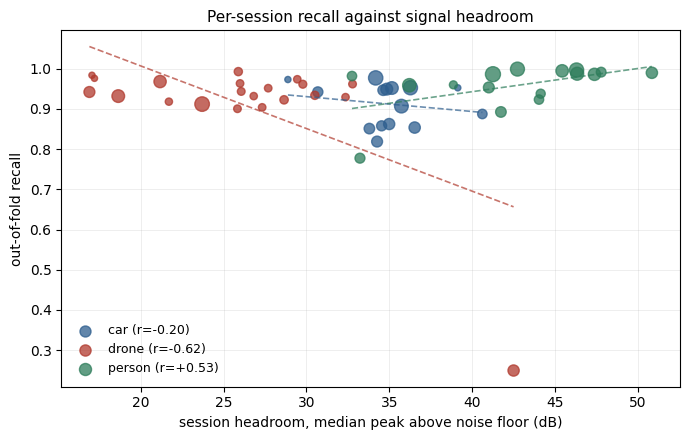

marker size is session sample count


In [ ]:
import json, matplotlib.pyplot as plt, numpy as np

rep = json.load(open(os.path.join(DIRS['reports'], 'step2c_sessions.json')))
fig, ax = plt.subplots(figsize=(7, 4.5))
colours = {'car': '#2E5E8E', 'drone': '#B03A2E', 'person': '#2E7D5B'}
for c, r in rep.items():
    x = [s['ptf_median'] for s in r['sessions']]
    y = [s['recall'] for s in r['sessions']]
    n = [s['n'] for s in r['sessions']]
    ax.scatter(x, y, s=[max(20, v / 6) for v in n], alpha=0.75,
               color=colours.get(c, 'grey'),
               label='%s (r=%+.2f)' % (c, r['pearson']))
    if len(x) > 2 and np.std(x) > 0:
        z = np.polyfit(x, y, 1)
        xs = np.linspace(min(x), max(x), 20)
        ax.plot(xs, np.polyval(z, xs), color=colours.get(c, 'grey'),
                linewidth=1.2, linestyle='--', alpha=0.7)
ax.set_xlabel('session headroom, median peak above noise floor (dB)')
ax.set_ylabel('out-of-fold recall')
ax.grid(alpha=0.25, linewidth=0.6)
ax.set_axisbelow(True)
ax.legend(frameon=False, fontsize=9)
ax.set_title('Per-session recall against signal headroom', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(DIRS['figures'], 'recall_vs_headroom.png'), dpi=200)
plt.show()
print('marker size is session sample count')

## What to send back

1. Cell 19 — the three per-session tables and the summary block.
2. Cell 20 — the figure.

**What each outcome means.**

If drone recall rises with headroom and the correlation is significant, that
is the mechanism demonstrated without compression, and it should lead the
paper. The compression grid then becomes confirmation of a mechanism you
have already established rather than the sole evidence for it.

If it does not correlate, the cross-session variance is still real and still
worth reporting, but headroom is not the explanation and the framing needs
rethinking before the grid runs. Look at the low-recall sessions in the
table and ask what else they share — sample count, time of day, whichever
trajectory type they came from.

Either way, do not skip to the compression grid until this is answered. A
grid built on an unverified mechanism is a grid you may have to throw
away.

---

# Step 2d — What is different about drone session 13-48?

**Step 2c did not support the headroom mechanism.** The drone correlation of
r = -0.62 collapses to -0.16 once `13-48` is removed, and the Pearson versus
Spearman gap (-0.62 against -0.25) was the tell that one point was doing all
the work.

**A correction to what Step 2b appeared to show.** Without `13-48`, drone
recall sd is 0.0262, against 0.0505 for cars and 0.0549 for people. Drones
generalise across sessions *better* than either other class. The variance
asymmetry, and fold 3's collapse, were one recording.

So the project currently has no supported mechanism. Three have been
proposed and all three failed against data: rotor sidebands, refuted by the
Doppler span arithmetic; cell-count redundancy, refuted by the corrected
concentration metric; headroom, refuted here.

This notebook is therefore **deliberately descriptive**. It measures twelve
properties and reports which ones separate `13-48`, rather than testing one
story that happens to be appealing.

- **[A]** twelve properties per session, with z-scores against the rest of
  the drone distribution
- **[B]** where the errors go, and which class centroid the samples sit
  nearest — a labelling check
- **[C]** the decisive one. Put half of `13-48` into training and test on
  the other half. Large recovery means coverage; little recovery means the
  recording is intrinsically hard or mislabelled

## 21. Write the Step 2d module

In [ ]:
%%writefile /content/src/step2d.py
"""
Step 2d: what is different about drone session 13-48?

Context. Session 13-48 sits at 42.5 dB headroom, nearly 10 dB above any
other drone recording, and scores 0.2494 out-of-fold recall against 0.90 to
0.99 everywhere else. It alone produced the fold-3 collapse in Step 2b and
the apparent headroom correlation in Step 2c. Remove it and drone recall sd
falls from 0.1504 to 0.0262, which is LOWER than car (0.0505) or person
(0.0549).

Deliberately descriptive first. Three mechanisms have already been proposed
for this project and all three failed against data, so this measures a broad
set of properties and reports which ones actually separate 13-48, rather
than testing one story I find appealing.

  A  Descriptive profile. Twelve measurable properties per session, with
     13-48's z-score against the rest of the drone distribution. Whatever
     is different should announce itself.

  B  Where the errors go. Confusion for 13-48 specifically, plus which
     class centroid its samples sit nearest.

  C  Coverage test. THE DECISIVE ONE. Put half of 13-48 into training and
     test on the other half. If recall recovers, the model simply had no
     comparable training data and this is a dataset coverage finding. If it
     stays low, the recording is intrinsically hard or mislabelled, which
     is a different and less interesting story.

Usage:
    python step2d.py --data DIR/dataset.npz --target drone/13-48
"""

import argparse
import json
import os
import sys
from collections import defaultdict

import numpy as np

sys.path.insert(0, os.path.dirname(os.path.abspath(__file__)))
from step2 import CLASSES, make_model
from step2b import normalise


# ------------------------------------------------------------------ A

def sample_features(X):
    """Twelve descriptive properties per sample, in physical terms."""
    n, H, W = X.shape
    flat = X.reshape(n, -1)
    peak = flat.max(axis=1)
    lin = 10.0 ** ((X - peak[:, None, None]) / 10.0)
    linf = lin.reshape(n, -1)
    floor = np.median(linf, axis=1)

    arg = flat.argmax(axis=1)
    prow, pcol = arg // W, arg % W

    excess = np.maximum(linf - floor[:, None], 0.0)
    tot = excess.sum(axis=1)
    tot[tot == 0] = 1e-12
    e2 = excess.reshape(n, H, W)
    rows = np.arange(H)[None, :]
    cols = np.arange(W)[None, :]
    rmass = e2.sum(axis=2)
    cmass = e2.sum(axis=1)
    rcent = (rmass * rows).sum(1) / np.maximum(rmass.sum(1), 1e-12)
    ccent = (cmass * cols).sum(1) / np.maximum(cmass.sum(1), 1e-12)
    rspread = np.sqrt((rmass * (rows - rcent[:, None]) ** 2).sum(1)
                      / np.maximum(rmass.sum(1), 1e-12))
    cspread = np.sqrt((cmass * (cols - ccent[:, None]) ** 2).sum(1)
                      / np.maximum(cmass.sum(1), 1e-12))

    return {
        "peak_dB": peak,
        "headroom_dB": -10 * np.log10(np.maximum(floor, 1e-30)),
        "peak_range_bin": prow.astype(float),
        "peak_doppler_bin": pcol.astype(float),
        "range_centroid": rcent,
        "doppler_centroid": ccent,
        "range_spread": rspread,
        "doppler_spread": cspread,
        "cells_within_10dB": (linf > 10 ** -1.0).sum(axis=1).astype(float),
        "cells_within_20dB": (linf > 10 ** -2.0).sum(axis=1).astype(float),
        "dynamic_range_dB": peak - flat.min(axis=1),
        "mean_dB": flat.mean(axis=1),
    }


def profile(X, y, unit, target):
    feats = sample_features(X)
    tcls = target.split("/")[0]
    tmask = unit == target
    omask = (y == tcls) & ~tmask
    print("=" * 76)
    print("[A] DESCRIPTIVE PROFILE  %s  (n=%d) vs other %s sessions (n=%d)"
          % (target, int(tmask.sum()), tcls, int(omask.sum())))
    print("=" * 76)
    print("  %-20s %12s %12s %10s   %s"
          % ("property", target.split("/")[-1], "others", "z", ""))
    out = {}
    for name, v in feats.items():
        a, b = v[tmask], v[omask]
        z = (a.mean() - b.mean()) / (b.std() + 1e-9)
        flag = "  <== OUTLIER" if abs(z) > 2.0 else ""
        print("  %-20s %12.2f %12.2f %10.2f%s"
              % (name, a.mean(), b.mean(), z, flag))
        out[name] = {"target": float(a.mean()), "others": float(b.mean()),
                     "z": float(z)}
    big = sorted(out, key=lambda k: -abs(out[k]["z"]))[:3]
    print("\n  Most distinguishing: %s" % ", ".join(
        "%s (z=%+.1f)" % (k, out[k]["z"]) for k in big))
    return out


# ------------------------------------------------------------------ B

def nearest_class(X, y, unit, target):
    """Which class centroid do the target's samples sit nearest?"""
    Xn = normalise(X, "offset")[:, 0].reshape(len(X), -1)
    Xn = Xn / (np.linalg.norm(Xn, axis=1, keepdims=True) + 1e-9)
    tmask = unit == target
    cents = {}
    for c in CLASSES:
        m = (y == c) & ~tmask
        v = Xn[m].mean(axis=0)
        cents[c] = v / (np.linalg.norm(v) + 1e-9)
    M = np.stack([cents[c] for c in CLASSES])
    sim = Xn[tmask] @ M.T
    win = sim.argmax(axis=1)
    print("\n" + "=" * 76)
    print("[B] NEAREST CLASS CENTROID for %s samples" % target)
    print("=" * 76)
    for i, c in enumerate(CLASSES):
        print("    %-8s mean similarity %+.4f   nearest for %5.1f%% of samples"
              % (c, sim[:, i].mean(), 100.0 * (win == i).mean()))
    tc = target.split("/")[0]
    if CLASSES[int(np.bincount(win, minlength=3).argmax())] != tc:
        print("    The samples sit closer to a DIFFERENT class centroid than")
        print("    their own label. Worth checking the labelling of this")
        print("    recording before building any story on it.")
    return {CLASSES[i]: {"mean_sim": float(sim[:, i].mean()),
                         "frac_nearest": float((win == i).mean())}
            for i in range(3)}


# ------------------------------------------------------------------ C

def train_eval(Xn, yi, tr, va, te, seed, epochs):
    import torch
    import torch.nn as nn
    torch.manual_seed(seed)
    np.random.seed(seed)
    dev = "cuda" if torch.cuda.is_available() else "cpu"
    Xtr = torch.tensor(Xn[tr]); ytr = torch.tensor(yi[tr])
    Xva = torch.tensor(Xn[va]); yva = torch.tensor(yi[va])
    Xte = torch.tensor(Xn[te])
    model = make_model(torch, nn).to(dev)
    opt = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.OneCycleLR(
        opt, max_lr=3e-3, total_steps=epochs * max(1, len(Xtr) // 128 + 1))
    lossf = nn.CrossEntropyLoss()
    best, state, bad = -1.0, None, 0
    for _ in range(epochs):
        model.train()
        perm = torch.randperm(len(Xtr))
        for i in range(0, len(perm), 128):
            j = perm[i:i + 128]
            opt.zero_grad()
            lossf(model(Xtr[j].to(dev)), ytr[j].to(dev)).backward()
            opt.step()
            try:
                sched.step()
            except Exception:
                pass
        model.eval()
        with torch.no_grad():
            pv = [model(Xva[i:i + 512].to(dev)).argmax(1).cpu()
                  for i in range(0, len(Xva), 512)]
            acc = (torch.cat(pv) == yva).float().mean().item()
        if acc > best:
            best, bad = acc, 0
            state = {k: v.detach().cpu().clone()
                     for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= 10:
                break
    model.load_state_dict(state)
    model.eval()
    with torch.no_grad():
        pt = [model(Xte[i:i + 512].to(dev)).argmax(1).cpu()
              for i in range(0, len(Xte), 512)]
    return torch.cat(pt).numpy()


def coverage_test(X, y, unit, target, seeds, epochs):
    """
    Held-out: target entirely excluded from training (the k-fold situation).
    Included: half of target in training, evaluate on the other half.

    A large recovery means the model lacked comparable training data, which
    is a coverage finding. Little recovery means the recording is
    intrinsically hard or mislabelled.
    """
    Xn = normalise(X, "offset")
    cls_idx = {c: i for i, c in enumerate(CLASSES)}
    yi = np.array([cls_idx[c] for c in y])
    tidx = np.where(unit == target)[0]

    print("\n" + "=" * 76)
    print("[C] COVERAGE TEST for %s" % target)
    print("=" * 76)
    res = {}
    for seed in seeds:
        rng = np.random.default_rng(seed)
        perm = rng.permutation(tidx)
        half_a, half_b = perm[:len(perm) // 2], perm[len(perm) // 2:]

        others = np.where(unit != target)[0]
        rng.shuffle(others)
        n_val = int(0.15 * len(others))
        val_o, tr_o = others[:n_val], others[n_val:]

        for name, extra in (("held out", np.array([], dtype=int)),
                            ("half included", half_a)):
            tr = np.zeros(len(y), dtype=bool)
            tr[tr_o] = True
            tr[extra] = True
            va = np.zeros(len(y), dtype=bool)
            va[val_o] = True
            te = np.zeros(len(y), dtype=bool)
            te[half_b] = True

            pred = train_eval(Xn, yi, tr, va, te, seed, epochs)
            true = yi[te]
            rec = float((pred == true).mean())
            dist = {CLASSES[i]: int((pred == i).sum()) for i in range(3)}
            res.setdefault(name, []).append(rec)
            print("    seed %d  %-14s recall on held-back half: %.4f   %s"
                  % (seed, name, rec, dist))

    a = float(np.mean(res["held out"]))
    b = float(np.mean(res["half included"]))
    print("\n    held out      %.4f" % a)
    print("    half included %.4f   (recovery %+.4f)" % (b, b - a))
    print("")
    if b - a > 0.30:
        print("    Large recovery. The model simply had no comparable training")
        print("    data for this recording. This is a DATASET COVERAGE")
        print("    finding: one flight regime out of twenty-one is effectively")
        print("    unrepresented, and standard evaluation hides it entirely.")
    elif b - a > 0.10:
        print("    Partial recovery. Coverage explains some of it, but the")
        print("    recording is also harder than the rest on its own terms.")
    else:
        print("    Little recovery. Not a coverage problem. The recording is")
        print("    intrinsically hard or mislabelled -- check [A] and [B]")
        print("    before drawing any conclusion from it.")
    return {"held_out": a, "half_included": b, "recovery": b - a,
            "runs": {k: [float(x) for x in v] for k, v in res.items()}}


# ------------------------------------------------------------------ main

def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--data", required=True)
    ap.add_argument("--target", default="drone/13-48")
    ap.add_argument("--seeds", type=int, nargs="+", default=[0, 1])
    ap.add_argument("--epochs", type=int, default=40)
    ap.add_argument("--out", default=None)
    args = ap.parse_args()

    d = np.load(args.data, allow_pickle=False)
    X, y, unit = d["X"], d["y"], d["unit"]
    if not (unit == args.target).any():
        avail = sorted({u for u in unit.tolist()
                        if u.startswith(args.target.split("/")[0])})
        raise SystemExit("target not found. available: %s" % avail)

    rep = {"target": args.target}
    rep["profile"] = profile(X, y, unit, args.target)
    rep["nearest"] = nearest_class(X, y, unit, args.target)
    rep["coverage"] = coverage_test(X, y, unit, args.target,
                                    args.seeds, args.epochs)

    if args.out:
        json.dump(rep, open(args.out, "w"), indent=2)
        print("\n  written %s" % args.out)


if __name__ == "__main__":
    main()


Writing /content/src/step2d.py


In [ ]:
shutil.copy('/content/src/step2d.py', os.path.join(DIRS['src'], 'step2d.py'))
print('ok')

ok


## 22. Run the diagnostic

About 10 to 20 minutes on a T4 (four trainings).

In [ ]:
proc = subprocess.run(
    [sys.executable, 'step2d.py',
     '--data', os.path.join(DATA_DIR, 'dataset.npz'),
     '--target', 'drone/13-48', '--seeds', '0', '1', '--epochs', '40',
     '--out', os.path.join(DIRS['reports'], 'step2d_13-48.json')],
    cwd=LOCAL_SRC, capture_output=True, text=True)
print(proc.stdout[-8000:])
if proc.returncode:
    print(proc.stderr[-3000:])

[A] DESCRIPTIVE PROFILE  drone/13-48  (n=393) vs other drone sessions (n=4672)
  property                    13-48       others          z   
  peak_dB                    -72.33       -88.95       2.26  <== OUTLIER
  headroom_dB                 43.74        24.70       2.57  <== OUTLIER
  peak_range_bin               4.80         4.90      -0.16
  peak_doppler_bin             7.58        30.01      -8.16  <== OUTLIER
  range_centroid               4.92         4.96      -0.10
  doppler_centroid             8.50        30.04     -15.67  <== OUTLIER
  range_spread                 2.41         1.91       0.70
  doppler_spread               6.10        10.06      -0.89
  cells_within_10dB           15.71        29.59      -0.22
  cells_within_20dB           41.46       199.52      -0.77
  dynamic_range_dB            72.95        53.99       2.07  <== OUTLIER
  mean_dB                   -115.82      -114.33      -0.59

  Most distinguishing: doppler_centroid (z=-15.7), peak_doppler_bin (z=-

## 23. Look at the samples

Numbers say what is different; images say whether it looks like a drone at
all.

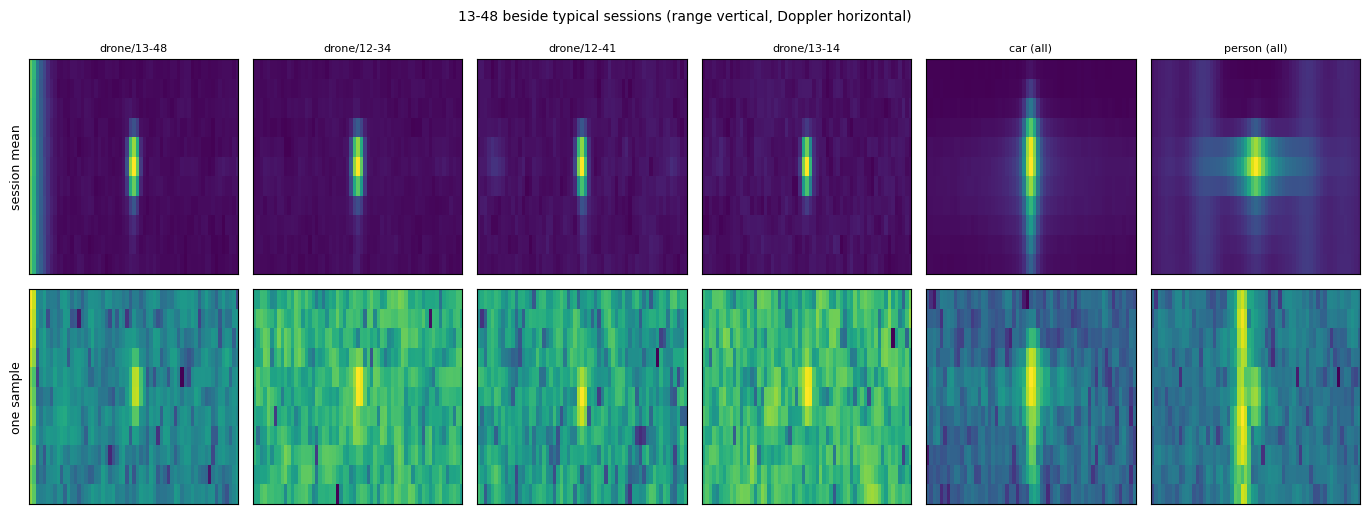


Doppler centroid of peak, per drone session:
  12-34              30.2  (sd   1.6, n=660)
  12-41              30.1  (sd   4.2, n=500)
  13-14              30.0  (sd   4.6, n=372)
  13-21              30.0  (sd   2.2, n=471)
  13-48               7.6  (sd  12.1, n=393)   <== target
  15-16              31.3  (sd   6.0, n=31)
  15-18              28.6  (sd   4.2, n=42)
  15-21              29.8  (sd   1.2, n=181)
  15-24              29.7  (sd   3.5, n=169)
  15-30              29.8  (sd   0.4, n=212)
  15-33              30.1  (sd   1.9, n=177)
  15-36              30.5  (sd   4.0, n=165)
  15-38              29.9  (sd   3.4, n=176)
  15-42              30.2  (sd   3.4, n=186)
  15-44              30.0  (sd   1.0, n=170)
  15-47              29.8  (sd   1.8, n=195)
  15-50              29.8  (sd   0.4, n=172)
  16-09              29.9  (sd   0.5, n=220)
  16-11              29.8  (sd   0.5, n=184)
  16-15              29.9  (sd   0.4, n=211)
  16-17              30.3  (sd   3.1, n=178

In [ ]:
import numpy as np, matplotlib.pyplot as plt

d = np.load(os.path.join(DATA_DIR, 'dataset.npz'), allow_pickle=False)
X, y, unit = d['X'], d['y'], d['unit']
TARGET = 'drone/13-48'

others = sorted({u for u in unit.tolist()
                 if u.startswith('drone/') and u != TARGET})[:3]
panels = [(TARGET, unit == TARGET)]
panels += [(u, unit == u) for u in others]
panels += [('car (all)', y == 'car'), ('person (all)', y == 'person')]

fig, axes = plt.subplots(2, len(panels), figsize=(2.3 * len(panels), 5.2))
for k, (name, m) in enumerate(panels):
    mean = X[m].mean(axis=0)
    axes[0, k].imshow(mean, aspect='auto', cmap='viridis')
    axes[0, k].set_title(name, fontsize=8)
    axes[0, k].set_xticks([]); axes[0, k].set_yticks([])
    j = np.where(m)[0][len(np.where(m)[0]) // 2]
    axes[1, k].imshow(X[j], aspect='auto', cmap='viridis')
    axes[1, k].set_xticks([]); axes[1, k].set_yticks([])
axes[0, 0].set_ylabel('session mean', fontsize=9)
axes[1, 0].set_ylabel('one sample', fontsize=9)
plt.suptitle('13-48 beside typical sessions (range vertical, Doppler horizontal)',
             fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(DIRS['figures'], 'session_13-48_vs_others.png'), dpi=200)
plt.show()

# per-session Doppler centroid: is 13-48 sitting somewhere unusual?
W = X.shape[2]
print('\nDoppler centroid of peak, per drone session:')
for u in sorted({v for v in unit.tolist() if v.startswith('drone/')}):
    m = unit == u
    cols = X[m].reshape(m.sum(), -1).argmax(axis=1) % W
    mark = '   <== target' if u == TARGET else ''
    print('  %-16s %6.1f  (sd %5.1f, n=%d)%s'
          % (u.split("/")[1], cols.mean(), cols.std(), m.sum(), mark))

## 22b. Ten seeds on the coverage test

The coverage result is the paper's principal finding and it was run on two
seeds, while the compression follow-up used ten. That asymmetry is hard to
defend in review: the secondary result got five times the statistical
attention of the primary one.

This reruns the identical experiment on ten seeds and writes it to a new
file rather than overwriting the two-seed report, so both survive and the
numbers can be compared rather than silently replaced. Expect roughly five
times the runtime of the original cell.


In [ ]:
# ---- ten-seed coverage test on 13-48 ------------------------------------
import subprocess, sys, os

REPO    = '/content/rdrd-acquisition-coverage'
PROJECT = '/content/drive/MyDrive/radar_compression'

if os.path.isdir(os.path.join(REPO, '.git')):
    subprocess.run(['git', '-C', REPO, 'pull', '--ff-only'],
                   capture_output=True, text=True)
else:
    subprocess.run(['git', 'clone', '--depth', '1',
                    'https://github.com/falcon-colab/'
                    'rdrd-acquisition-coverage', REPO],
                   capture_output=True, text=True, check=True)

proc = subprocess.run(
    [sys.executable, os.path.join(REPO, 'src', 'step2d.py'),
     '--data',   os.path.join(PROJECT, 'cache', 'dataset.npz'),
     '--target', 'drone/13-48',
     '--seeds',  '0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
     '--epochs', '40',
     '--out',    os.path.join(PROJECT, 'reports',
                              'step2d_13-48_10seeds.json')],
    capture_output=True, text=True)
print(proc.stdout[-8000:])
if proc.returncode:
    print(proc.stderr[-3000:])


## 22c. The same test on a control acquisition

The coverage experiment has so far been run on `13-48` and nowhere else, so
there is no evidence that a large recovery is unusual. Acquisitions at 0.78
to 0.83 exist in the other two classes, and a reviewer is entitled to ask
why 0.249 is a coverage failure while 0.7776 is not.

This picks the weakest non-drone acquisition out of the step 2c report
rather than naming one by hand, and runs the identical experiment on it.
Either outcome is worth having. Little recovery says `13-48` is a distinct
phenomenon and the others are ordinary difficulty. A comparable recovery
says coverage effects are general across this benchmark, which is a larger
claim than the paper currently makes and would need the argument rewritten.


In [ ]:
# ---- the same coverage test on a control acquisition ---------------------
import json, subprocess, sys, os

REPO    = '/content/rdrd-acquisition-coverage'
PROJECT = '/content/drive/MyDrive/radar_compression'
REPORTS = os.path.join(PROJECT, 'reports')

if os.path.isdir(os.path.join(REPO, '.git')):
    subprocess.run(['git', '-C', REPO, 'pull', '--ff-only'],
                   capture_output=True, text=True)
else:
    subprocess.run(['git', 'clone', '--depth', '1',
                    'https://github.com/falcon-colab/'
                    'rdrd-acquisition-coverage', REPO],
                   capture_output=True, text=True, check=True)

# choose the control from the data, not from memory: the weakest acquisition
# in either non-drone class
rep = json.load(open(os.path.join(REPORTS, 'step2c_sessions.json')))
worst, worst_recall = None, 2.0
for cls in ('car', 'person'):
    for s in rep[cls]['sessions']:
        if s['recall'] < worst_recall:
            worst, worst_recall = '%s/%s' % (cls, s['name']), s['recall']

print('control acquisition: %s  (out-of-fold recall %.4f)'
      % (worst, worst_recall))
print('comparison          : drone/13-48 at 0.2494\n')

proc = subprocess.run(
    [sys.executable, os.path.join(REPO, 'src', 'step2d.py'),
     '--data',   os.path.join(PROJECT, 'cache', 'dataset.npz'),
     '--target', worst,
     '--seeds',  '0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
     '--epochs', '40',
     '--out',    os.path.join(REPORTS, 'step2d_control.json')],
    capture_output=True, text=True)
print(proc.stdout[-8000:])
if proc.returncode:
    print(proc.stderr[-3000:])


## 22d. A second control, from the vehicle class

The first control, `11-23`, turned out to be impure: 56.8 % of its samples
sit nearest the drone class centroid rather than their own, so it is
confusable with another class as well as being hard. That makes it a fair
test of whether a large recovery is generic, and a weak test of whether
*only* 13-48 is unrepresented.

This runs the same experiment on `15-37`, the weakest vehicle acquisition at
0.8189. If its nearest-centroid check is clean, it is the purer control, and
two controls recovering almost nothing is a much harder result to dismiss
than one.


In [ ]:
import subprocess, sys, os

REPO    = '/content/rdrd-acquisition-coverage'
PROJECT = '/content/drive/MyDrive/radar_compression'
REPORTS = os.path.join(PROJECT, 'reports')

if os.path.isdir(os.path.join(REPO, '.git')):
    subprocess.run(['git', '-C', REPO, 'pull', '--ff-only'],
                   capture_output=True, text=True)
else:
    subprocess.run(['git', 'clone', '--depth', '1',
                    'https://github.com/falcon-colab/'
                    'rdrd-acquisition-coverage', REPO],
                   capture_output=True, text=True, check=True)

proc = subprocess.run(
    [sys.executable, os.path.join(REPO, 'src', 'step2d.py'),
     '--data',   os.path.join(PROJECT, 'cache', 'dataset.npz'),
     '--target', 'car/15-37',
     '--seeds',  '0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
     '--epochs', '40',
     '--out',    os.path.join(REPORTS, 'step2d_control2.json')],
    capture_output=True, text=True)
print(proc.stdout[-8000:])
if proc.returncode:
    print(proc.stderr[-3000:])


## 22e. The accuracy gap against the published baselines

This is the experiment with the largest effect on how the paper is received.

The manuscript reports 0.9335 under random partitioning. The published
baselines report 99.48 % and 98.08 % under the same protocol. A reviewer can
reasonably answer the whole paper with: you found a failure mode of a weaker
model, not a property of the benchmark.

The sweep below tests the two cheapest explanations, capacity and training
length. Read the outcome either way:

- **Accuracy climbs toward 0.98.** The gap was ours. Rerun the coverage test
  at that configuration, and if 13-48 still fails at published accuracy the
  objection disappears entirely.
- **Accuracy plateaus near 0.93.** The gap is not capacity or schedule, and
  the Limitations paragraph becomes a measurement rather than a concession.

Runtime is the product of the grid. The default is three widths by two epoch
counts by two seeds, twelve runs, several of them on a model three times the
size of the paper's. Start with `--scale 1.0 2.0` if GPU time is tight.


In [ ]:
import subprocess, sys, os

REPO    = '/content/rdrd-acquisition-coverage'
PROJECT = '/content/drive/MyDrive/radar_compression'
REPORTS = os.path.join(PROJECT, 'reports')

if os.path.isdir(os.path.join(REPO, '.git')):
    subprocess.run(['git', '-C', REPO, 'pull', '--ff-only'],
                   capture_output=True, text=True)
else:
    subprocess.run(['git', 'clone', '--depth', '1',
                    'https://github.com/falcon-colab/'
                    'rdrd-acquisition-coverage', REPO],
                   capture_output=True, text=True, check=True)

proc = subprocess.run(
    [sys.executable, os.path.join(REPO, 'src', 'capacity.py'),
     '--data',   os.path.join(PROJECT, 'cache', 'dataset.npz'),
     '--seeds',  '0', '1',
     '--epochs', '40', '80',
     '--scale',  '1.0', '2.0', '3.0',
     '--out',    os.path.join(REPORTS, 'capacity.json')],
    capture_output=True, text=True)
print(proc.stdout[-8000:])
if proc.returncode:
    print(proc.stderr[-3000:])


## What to send back

All of cells 22 and 23.

**Reading [C], which is the one that matters.**

Large recovery (say above +0.30) means the model had no comparable training
data. That is a dataset coverage finding: one flight regime out of
twenty-one is effectively unrepresented and standard evaluation hides it
completely. Real, measured, defensible, and smaller than the paper we
planned.

Little recovery means it is not coverage. Then [A] and [B] have to explain
it, and if [B] shows the samples sitting nearest a different class centroid,
the labelling of that recording needs checking before anything is built on
it.

Either way, this should be settled before talking to your professor, because
the conversation about reframing goes better with an explanation for the one
anomaly than without one.

---

# Step 3 — The compression grid

**Read this before running.** The grid was originally motivated by a
mechanism predicting drones would degrade first. Three such mechanisms were
proposed and all three failed against data. The grid therefore runs as an
**empirical audit with no predicted outcome**, plus one question that does
come from a supported finding:

> Does compression widen the gap on an unseen flight regime?

Step 2d showed `drone/13-48` is a regime absent from the other twenty drone
recordings: held out, recall 0.157; given half of it in training, 0.967. If
compression widens that gap, an embedded deployment is worse on exactly the
case standard evaluation already hides.

**Two axes.**

*Resolution* aggregates Doppler bins at 1x, 2x, 4x, 8x. Aggregation is
**incoherent** — linear power summed across adjacent magnitude bins. It is
not a shorter coherent processing interval, because the dataset publishes
magnitude only and the phase needed for that does not exist. It is reported
as input tensor resolution, never as CPI. Verified to conserve total linear
power exactly.

*Precision* quantises input and weights to 32/16/8/4 bits. Normalisation is
`offset`, a fixed affine map, so quantising before or after normalisation is
equivalent up to scale — which is why `offset` was chosen in Step 2b.

**Two evaluations:** the standard grouped split, and `13-48` held out
entirely and evaluated on alone.

## 24. Write the Step 3 module

In [ ]:
%%writefile /content/src/step3.py
"""
Step 3: the compression grid.

Framing note. This grid was originally motivated by a physical mechanism
predicting that drones would degrade first. Three such mechanisms were
proposed and all three failed against data (rotor sidebands, cell-count
redundancy, dynamic-range headroom). The grid is therefore run as an
EMPIRICAL AUDIT with no predicted outcome, plus one motivated question that
does come from a supported finding:

    Does compression widen the gap on an UNSEEN FLIGHT REGIME?

Step 2d established that session drone/13-48 is a regime absent from the
other twenty drone recordings: held out, recall is 0.157; given half of it
in training, 0.967. If compression widens that gap, an embedded deployment
is worse on exactly the case standard evaluation already hides.

Two axes:

  resolution  Doppler-axis aggregation at 1x, 2x, 4x, 8x. Aggregation is
              INCOHERENT (power summed across adjacent magnitude bins). It
              is NOT a shorter coherent processing interval -- the dataset
              publishes magnitude only, so the phase needed for that does
              not exist. Reported as "input tensor resolution", never as CPI.

  precision   Uniform quantisation of input and weights to 32/16/8/4 bits.
              Normalisation is 'offset', a fixed affine map, so quantising
              before or after normalisation is equivalent up to scale. That
              is why 'offset' was chosen in Step 2b.

Two evaluations:

  standard    the frozen grouped split
  unseen      drone/13-48 held out of training entirely, evaluated on it

Usage:
    python step3.py grid    --data DIR/dataset.npz --seeds 0 1
    python step3.py ablate  --data DIR/dataset.npz --seeds 0 1
"""

import argparse
import json
import os
import sys
from collections import defaultdict

import numpy as np

sys.path.insert(0, os.path.dirname(os.path.abspath(__file__)))
from step2 import CLASSES, make_model
from step2b import normalise, make_grouped_folds, split_for_fold

TARGET = "drone/13-48"


# ------------------------------------------------------------ compression

def reduce_doppler(X, factor):
    """
    Aggregate `factor` adjacent Doppler bins by summing LINEAR power, then
    return to dB. Summing dB values would be meaningless.

    This is incoherent aggregation. It reduces the size of the input tensor,
    which is a real memory cost on an embedded target. It is not equivalent
    to shortening the coherent processing interval, and must not be
    described as such.
    """
    if factor == 1:
        return X
    n, H, W = X.shape
    keep = (W // factor) * factor
    lin = 10.0 ** (X[:, :, :keep] / 10.0)
    lin = lin.reshape(n, H, keep // factor, factor).sum(axis=3)
    return (10.0 * np.log10(np.maximum(lin, 1e-30))).astype(np.float32)


def quantise(a, bits, lo=None, hi=None):
    """Uniform symmetric quantisation to `bits`, returned dequantised."""
    if bits >= 32:
        return a
    lo = a.min() if lo is None else lo
    hi = a.max() if hi is None else hi
    if hi <= lo:
        return a
    levels = 2 ** bits - 1
    step = (hi - lo) / levels
    return (np.round((np.clip(a, lo, hi) - lo) / step) * step + lo).astype(a.dtype)


def quantise_weights(model, bits):
    """Post-training fake-quant of conv and linear weights, per tensor."""
    import torch
    if bits >= 32:
        return
    with torch.no_grad():
        for m in model.modules():
            if isinstance(m, (torch.nn.Conv2d, torch.nn.Linear)):
                w = m.weight.detach().cpu().numpy()
                m.weight.copy_(torch.tensor(
                    quantise(w, bits, -np.abs(w).max(), np.abs(w).max()),
                    device=m.weight.device))


# ------------------------------------------------------------------ train

def fit(Xn, yi, tr, va, seed, epochs, lr=3e-3, bs=128):
    import torch
    import torch.nn as nn
    torch.manual_seed(seed)
    np.random.seed(seed)
    dev = "cuda" if torch.cuda.is_available() else "cpu"
    Xtr = torch.tensor(Xn[tr]); ytr = torch.tensor(yi[tr])
    Xva = torch.tensor(Xn[va]); yva = torch.tensor(yi[va])
    model = make_model(torch, nn).to(dev)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.OneCycleLR(
        opt, max_lr=lr, total_steps=epochs * max(1, len(Xtr) // bs + 1))
    lossf = nn.CrossEntropyLoss()
    best, state, bad = -1.0, None, 0
    for _ in range(epochs):
        model.train()
        perm = torch.randperm(len(Xtr))
        for i in range(0, len(perm), bs):
            j = perm[i:i + bs]
            opt.zero_grad()
            lossf(model(Xtr[j].to(dev)), ytr[j].to(dev)).backward()
            opt.step()
            try:
                sched.step()
            except Exception:
                pass
        model.eval()
        with torch.no_grad():
            pv = [model(Xva[i:i + 512].to(dev)).argmax(1).cpu()
                  for i in range(0, len(Xva), 512)]
            acc = (torch.cat(pv) == yva).float().mean().item()
        if acc > best:
            best, bad = acc, 0
            state = {k: v.detach().cpu().clone()
                     for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= 10:
                break
    model.load_state_dict(state)
    return model


def evaluate(model, Xn, yi, mask):
    import torch
    dev = next(model.parameters()).device
    model.eval()
    Xte = torch.tensor(Xn[mask])
    with torch.no_grad():
        pt = [model(Xte[i:i + 512].to(dev)).argmax(1).cpu()
              for i in range(0, len(Xte), 512)]
    pred = torch.cat(pt).numpy()
    true = yi[mask]
    cm = np.zeros((3, 3), dtype=int)
    for t, p in zip(true, pred):
        cm[t, p] += 1
    out = {"accuracy": float((pred == true).mean()), "confusion": cm.tolist()}
    for i, c in enumerate(CLASSES):
        rec = cm[i, i] / max(1, cm[i].sum())
        pre = cm[i, i] / max(1, cm[:, i].sum())
        out[c] = {"recall": float(rec), "precision": float(pre),
                  "f1": float(2 * rec * pre / max(1e-9, rec + pre))}
    return out


def run_cell(X, yi, tr, va, te, factor, bits, seed, epochs,
             quant_input=True, quant_weights=True):
    Xr = reduce_doppler(X, factor)
    if quant_input and bits < 32:
        Xr = quantise(Xr, bits)
    Xn = normalise(Xr, "offset")
    model = fit(Xn, yi, tr, va, seed, epochs)
    if quant_weights:
        quantise_weights(model, bits)
    r = evaluate(model, Xn, yi, te)
    r["input_cells"] = int(Xr.shape[1] * Xr.shape[2])
    r["input_bytes"] = float(r["input_cells"] * bits / 8.0)
    return r


# ------------------------------------------------------------------ masks

def standard_masks(y, unit, seed):
    gfold = make_grouped_folds(y, unit, 5)
    return split_for_fold(gfold, 0, 5, y, unit, True, seed)


def unseen_masks(y, unit, seed):
    """13-48 excluded from training and validation; evaluated on it alone."""
    rng = np.random.default_rng(500 + seed)
    te = unit == TARGET
    pool = np.where(~te)[0]
    rng.shuffle(pool)
    n_val = int(0.15 * len(pool))
    va = np.zeros(len(y), dtype=bool); va[pool[:n_val]] = True
    tr = np.zeros(len(y), dtype=bool); tr[pool[n_val:]] = True
    return tr, va, te


# ------------------------------------------------------------------ main

def main():
    ap = argparse.ArgumentParser()
    sub = ap.add_subparsers(dest="cmd", required=True)
    for nm in ("grid", "ablate"):
        p = sub.add_parser(nm)
        p.add_argument("--data", required=True)
        p.add_argument("--seeds", type=int, nargs="+", default=[0, 1])
        p.add_argument("--epochs", type=int, default=40)
        p.add_argument("--out", default=None)
        p.add_argument("--factors", type=int, nargs="+", default=[1, 2, 4, 8])
        p.add_argument("--bits", type=int, nargs="+", default=[32, 16, 8, 4])
    args = ap.parse_args()

    d = np.load(args.data, allow_pickle=False)
    X, y, unit = d["X"], d["y"], d["unit"]
    cls_idx = {c: i for i, c in enumerate(CLASSES)}
    yi = np.array([cls_idx[c] for c in y])

    if args.cmd == "ablate":
        print("=" * 74)
        print("ABLATION at 4 bits, 4x reduction: which axis does the damage?")
        print("=" * 74)
        rows = []
        for qi, qw, name in ((False, False, "neither"),
                             (True, False, "input only"),
                             (False, True, "weights only"),
                             (True, True, "both")):
            accs, dro = [], []
            for s in args.seeds:
                tr, va, te = standard_masks(y, unit, s)
                r = run_cell(X, yi, tr, va, te, 4, 4, s, args.epochs, qi, qw)
                accs.append(r["accuracy"]); dro.append(r["drone"]["f1"])
            rows.append((name, float(np.mean(accs)), float(np.mean(dro))))
            print("  %-14s accuracy %.4f   drone F1 %.4f"
                  % (name, np.mean(accs), np.mean(dro)))
        base = rows[0][1]
        print("\n  Relative to no quantisation (%.4f):" % base)
        for name, a, _f in rows[1:]:
            print("    %-14s %+.4f" % (name, a - base))
        if args.out:
            json.dump([{"setting": r[0], "accuracy": r[1], "drone_f1": r[2]}
                       for r in rows], open(args.out, "w"), indent=2)
        return

    results = defaultdict(dict)
    for setting, maskfn in (("standard", standard_masks),
                            ("unseen", unseen_masks)):
        print("\n" + "=" * 74)
        print("SETTING: %s" % setting.upper())
        if setting == "unseen":
            print("  %s excluded from training; evaluated on it alone." % TARGET)
        print("=" * 74)
        for factor in args.factors:
            for bits in args.bits:
                accs, dro, cells, byts = [], [], None, None
                for s in args.seeds:
                    tr, va, te = maskfn(y, unit, s)
                    r = run_cell(X, yi, tr, va, te, factor, bits, s, args.epochs)
                    accs.append(r["accuracy"]); dro.append(r["drone"]["recall"])
                    cells, byts = r["input_cells"], r["input_bytes"]
                key = "%dx_%dbit" % (factor, bits)
                results[setting][key] = {
                    "factor": factor, "bits": bits,
                    "accuracy": float(np.mean(accs)),
                    "accuracy_sd": float(np.std(accs)),
                    "drone_recall": float(np.mean(dro)),
                    "drone_recall_sd": float(np.std(dro)),
                    "input_cells": cells, "input_bytes": byts}
                print("  %2dx %2d-bit  cells %4d  bytes %7.0f   acc %.4f   drone recall %.4f"
                      % (factor, bits, cells, byts,
                         np.mean(accs), np.mean(dro)))

    print("\n" + "=" * 74)
    print("DRONE RECALL GRID")
    print("=" * 74)
    for setting in ("standard", "unseen"):
        print("\n  %s" % setting)
        print("      %s" % "".join("%9d-bit" % b for b in args.bits))
        for f in args.factors:
            row = "  %2dx" % f
            for b in args.bits:
                row += "%13.4f" % results[setting]["%dx_%dbit" % (f, b)]["drone_recall"]
            print(row)

    print("\n" + "=" * 74)
    print("DOES COMPRESSION WIDEN THE UNSEEN-REGIME GAP?")
    print("=" * 74)
    print("      %s" % "".join("%9d-bit" % b for b in args.bits))
    gaps = {}
    for f in args.factors:
        row = "  %2dx" % f
        for b in args.bits:
            k = "%dx_%dbit" % (f, b)
            g = (results["standard"][k]["drone_recall"]
                 - results["unseen"][k]["drone_recall"])
            gaps[k] = g
            row += "%13.4f" % g
        print(row)
    base = gaps["%dx_%dbit" % (args.factors[0], args.bits[0])]
    worst = gaps["%dx_%dbit" % (args.factors[-1], args.bits[-1])]
    print("\n  gap at %dx/%d-bit (uncompressed): %.4f"
          % (args.factors[0], args.bits[0], base))
    print("  gap at %dx/%d-bit (most compressed): %.4f"
          % (args.factors[-1], args.bits[-1], worst))
    print("  change: %+.4f" % (worst - base))
    print("")
    if worst - base > 0.10:
        print("  Compression widens the unseen-regime gap. An embedded")
        print("  deployment is worse on exactly the case standard evaluation")
        print("  already hides. That is the result to lead this section with.")
    elif worst - base < -0.10:
        print("  Compression NARROWS the gap, which is counterintuitive and")
        print("  most likely means compression is hurting the standard case")
        print("  more than the unseen one. Check the absolute numbers before")
        print("  reading anything into it.")
    else:
        print("  Compression does not measurably change the gap. The coverage")
        print("  failure is independent of compression: report it as a null")
        print("  and keep the coverage finding as the paper's contribution.")

    if args.out:
        json.dump(results, open(args.out, "w"), indent=2)
        print("\n  written %s" % args.out)


if __name__ == "__main__":
    main()


Writing /content/src/step3.py


In [ ]:
shutil.copy('/content/src/step3.py', os.path.join(DIRS['src'], 'step3.py'))
print('ok')

ok


## 25. The grid

4 resolutions x 4 bit widths x 2 settings x 2 seeds = 64 trainings.
Roughly 2 to 4 hours on a T4. Start it and leave it.

If Colab disconnects, reduce to `--seeds 0` and `--bits 32 8 4` for a
32-run version first, then extend.

In [ ]:
proc = subprocess.run(
    [sys.executable, 'step3.py', 'grid',
     '--data', os.path.join(DATA_DIR, 'dataset.npz'),
     '--seeds', '0', '1', '--epochs', '40',
     '--out', os.path.join(DIRS['reports'], 'step3_grid.json')],
    cwd=LOCAL_SRC, capture_output=True, text=True)
print(proc.stdout[-9000:])
if proc.returncode:
    print(proc.stderr[-3000:])


SETTING: STANDARD
   1x 32-bit  cells  671  bytes    2684   acc 0.9357   drone recall 0.8952
   1x 16-bit  cells  671  bytes    1342   acc 0.9433   drone recall 0.9199
   1x  8-bit  cells  671  bytes     671   acc 0.9390   drone recall 0.8932
   1x  4-bit  cells  671  bytes     336   acc 0.8229   drone recall 0.6523
   2x 32-bit  cells  330  bytes    1320   acc 0.9479   drone recall 0.9154
   2x 16-bit  cells  330  bytes     660   acc 0.9442   drone recall 0.9041
   2x  8-bit  cells  330  bytes     330   acc 0.9449   drone recall 0.9080
   2x  4-bit  cells  330  bytes     165   acc 0.9068   drone recall 0.8417
   4x 32-bit  cells  165  bytes     660   acc 0.9461   drone recall 0.9288
   4x 16-bit  cells  165  bytes     330   acc 0.9475   drone recall 0.9209
   4x  8-bit  cells  165  bytes     165   acc 0.9388   drone recall 0.9045
   4x  4-bit  cells  165  bytes      82   acc 0.7504   drone recall 0.4120
   8x 32-bit  cells   77  bytes     308   acc 0.9185   drone recall 0.8506
   8x 

## 26. Which axis does the damage?

At the most aggressive corner, separate input quantisation from weight
quantisation. Eight trainings, about 20 minutes.

A reviewer will ask whether the effect is about the radar data or about the
network. This answers it.

In [ ]:
proc = subprocess.run(
    [sys.executable, 'step3.py', 'ablate',
     '--data', os.path.join(DATA_DIR, 'dataset.npz'),
     '--seeds', '0', '1', '--epochs', '40',
     '--out', os.path.join(DIRS['reports'], 'step3_ablate.json')],
    cwd=LOCAL_SRC, capture_output=True, text=True)
print(proc.stdout[-3000:])
if proc.returncode:
    print(proc.stderr[-3000:])

ABLATION at 4 bits, 4x reduction: which axis does the damage?
  neither        accuracy 0.9432   drone F1 0.9135
  input only     accuracy 0.9190   drone F1 0.8740
  weights only   accuracy 0.9080   drone F1 0.8523
  both           accuracy 0.7402   drone F1 0.4077

  Relative to no quantisation (0.9432):
    input only     -0.0241
    weights only   -0.0351
    both           -0.2030



## 27. Figures

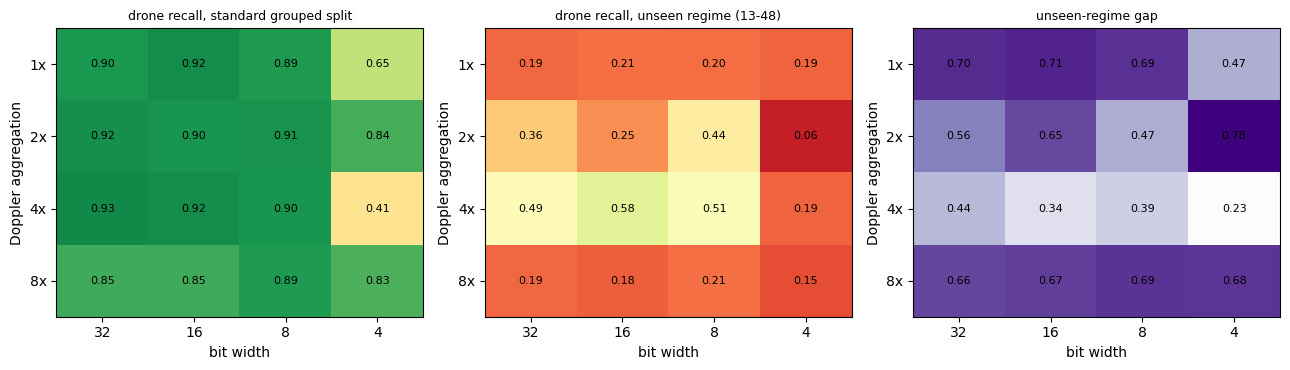

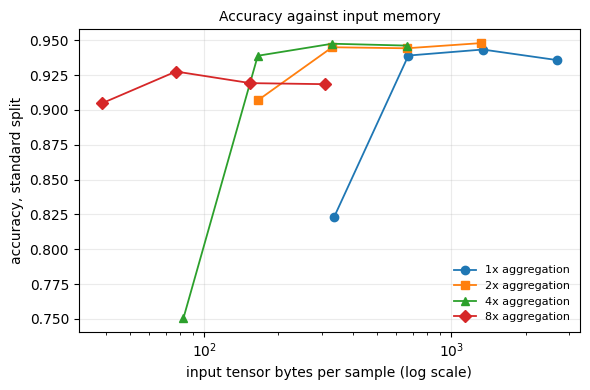

In [ ]:
import json, numpy as np, matplotlib.pyplot as plt

res = json.load(open(os.path.join(DIRS['reports'], 'step3_grid.json')))
factors, bits = [1, 2, 4, 8], [32, 16, 8, 4]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, (setting, title) in zip(
        axes[:2], [('standard', 'standard grouped split'),
                   ('unseen', 'unseen regime (13-48)')]):
    M = np.array([[res[setting]['%dx_%dbit' % (f, b)]['drone_recall']
                   for b in bits] for f in factors])
    im = ax.imshow(M, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(len(bits)));   ax.set_xticklabels(['%d' % b for b in bits])
    ax.set_yticks(range(len(factors))); ax.set_yticklabels(['%dx' % f for f in factors])
    ax.set_xlabel('bit width'); ax.set_ylabel('Doppler aggregation')
    ax.set_title('drone recall, ' + title, fontsize=9)
    for i in range(len(factors)):
        for j in range(len(bits)):
            ax.text(j, i, '%.2f' % M[i, j], ha='center', va='center', fontsize=8)

G = np.array([[res['standard']['%dx_%dbit' % (f, b)]['drone_recall']
               - res['unseen']['%dx_%dbit' % (f, b)]['drone_recall']
               for b in bits] for f in factors])
ax = axes[2]
im = ax.imshow(G, cmap='Purples', aspect='auto')
ax.set_xticks(range(len(bits)));   ax.set_xticklabels(['%d' % b for b in bits])
ax.set_yticks(range(len(factors))); ax.set_yticklabels(['%dx' % f for f in factors])
ax.set_xlabel('bit width'); ax.set_ylabel('Doppler aggregation')
ax.set_title('unseen-regime gap', fontsize=9)
for i in range(len(factors)):
    for j in range(len(bits)):
        ax.text(j, i, '%.2f' % G[i, j], ha='center', va='center', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(DIRS['figures'], 'compression_grid.png'), dpi=200)
plt.show()

# accuracy against input memory
fig, ax = plt.subplots(figsize=(6, 4))
for f, mk in zip(factors, ['o', 's', '^', 'D']):
    xs = [res['standard']['%dx_%dbit' % (f, b)]['input_bytes'] for b in bits]
    ys = [res['standard']['%dx_%dbit' % (f, b)]['accuracy'] for b in bits]
    ax.plot(xs, ys, marker=mk, linewidth=1.3, label='%dx aggregation' % f)
ax.set_xscale('log')
ax.set_xlabel('input tensor bytes per sample (log scale)')
ax.set_ylabel('accuracy, standard split')
ax.grid(alpha=0.25); ax.set_axisbelow(True)
ax.legend(frameon=False, fontsize=8)
ax.set_title('Accuracy against input memory', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(DIRS['figures'], 'accuracy_vs_memory.png'), dpi=200)
plt.show()

## What to send back

Cells 25, 26 and 27.

**How to read it.** The question is not whether compression hurts — it will.
It is whether the *gap* between the standard and unseen settings widens as
compression increases.

If the gap widens, that is a genuine safety result and leads this section.

If it does not, report a null. The coverage finding from Step 2d remains the
paper's contribution and the grid becomes an honest negative section, which
is worth publishing alongside it and costs you nothing you have not already
spent.

Either outcome is reportable. That was the point of designing it this
way.

---

# Step 4 — Confirm the Step 3 findings, and test the mechanism

**First, a correction.** The automated verdict at the end of Step 3 compared
only the two corner cells and reported no effect. That was a bad summary
statistic. Averaged along the aggregation axis, excluding the unstable
4-bit column:

| aggregation | mean gap | mean unseen recall |
|---|---|---|
| 1x | 0.643 | 0.201 |
| 2x | 0.614 | 0.350 |
| **4x** | **0.350** | **0.527** |
| 8x | 0.674 | 0.193 |

Four-times aggregation more than doubles unseen-regime recall and halves the
gap. Then 8x throws it away. A clear inverted U.

**And it has an explanation.** `13-48` fails because its target sits at an
anomalous Doppler *position*. Aggregating Doppler bins makes the classifier
less sensitive to position, so it generalises to a target sitting somewhere
it has never seen one. Push too far and the discriminative information goes
with it.

**Second finding.** The ablation showed input-only -0.024, weights-only
-0.035, both -0.203. Strongly superadditive.

Neither survives on two seeds. The noise is visible: `2x/8-bit` unseen
recall 0.44 against `2x/16-bit` 0.25, an ordering with no reason to be
real.

## 28. Write the Step 4 module

In [ ]:
%%writefile /content/src/step4.py
"""
Step 4: confirm the two Step 3 findings, and test the mechanism directly.

Step 3 produced two candidate results on two seeds each:

  1. Moderate Doppler aggregation partially rescues the unseen regime.
     Mean unseen-regime recall by aggregation (excluding the unstable
     4-bit column): 1x 0.20, 2x 0.35, 4x 0.53, 8x 0.19. An inverted U with
     a clear peak at 4x, and the gap halving from 0.64 to 0.35.

  2. Input and weight quantisation interact superadditively. At 4 bits and
     4x: input only -0.024, weights only -0.035, both -0.203.

Two seeds is not enough for either. Visible noise: 2x/8-bit unseen recall
0.44 against 2x/16-bit 0.25, an ordering with no reason to be real.

This does three things:

  seeds     Re-runs the aggregation axis at stable bit widths with more
            seeds, so we learn which effects survive.

  augment   THE MECHANISM TEST. If 4x aggregation helps because it makes
            the classifier less sensitive to Doppler POSITION, then
            augmenting training with Doppler shifts should produce the same
            rescue at full resolution -- and at no cost in resolution. If it
            does, the mechanism is confirmed AND you have a practical
            mitigation, which is what the proposal reviewers asked for. If
            it does not, the aggregation effect is something else.

  ablate    The quantisation interaction with more seeds.

Usage:
    python step4.py seeds   --data D --seeds 0 1 2 3 4
    python step4.py augment --data D --seeds 0 1 2 3 4
    python step4.py ablate  --data D --seeds 0 1 2 3 4
"""

import argparse
import json
import os
import sys

import numpy as np

sys.path.insert(0, os.path.dirname(os.path.abspath(__file__)))
from step2 import CLASSES
from step2b import normalise
from step3 import (reduce_doppler, quantise, quantise_weights, fit, evaluate,
                   standard_masks, unseen_masks, TARGET)


# ------------------------------------------------------- augmentation

def doppler_shift(X, max_shift, rng):
    """
    Shift each sample along the Doppler axis by a random amount, filling
    vacated cells with that sample's own noise floor.

    Deliberately NOT a circular roll: wrapping would move target energy from
    one Doppler edge to the other, which is not a physical operation and
    would teach the network something false.
    """
    n, H, W = X.shape
    out = np.empty_like(X)
    floor = np.median(X.reshape(n, -1), axis=1)
    shifts = rng.integers(-max_shift, max_shift + 1, n)
    for i in range(n):
        s = int(shifts[i])
        out[i] = floor[i]
        if s == 0:
            out[i] = X[i]
        elif s > 0:
            out[i, :, s:] = X[i, :, :W - s]
        else:
            out[i, :, :W + s] = X[i, :, -s:]
    return out


def fit_augmented(Xn, yi, tr, va, seed, epochs, X_raw, max_shift,
                  scheme="offset", bs=128, lr=3e-3):
    """Retrain with fresh Doppler shifts each epoch."""
    import torch
    import torch.nn as nn
    from step2 import make_model
    torch.manual_seed(seed)
    np.random.seed(seed)
    rng = np.random.default_rng(seed)
    dev = "cuda" if torch.cuda.is_available() else "cpu"

    idx_tr = np.where(tr)[0]
    ytr = torch.tensor(yi[idx_tr])
    Xva = torch.tensor(Xn[va]); yva = torch.tensor(yi[va])

    model = make_model(torch, nn).to(dev)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.OneCycleLR(
        opt, max_lr=lr, total_steps=epochs * max(1, len(idx_tr) // bs + 1))
    lossf = nn.CrossEntropyLoss()

    best, state, bad = -1.0, None, 0
    for _ep in range(epochs):
        Xa = normalise(doppler_shift(X_raw[idx_tr], max_shift, rng), scheme)
        Xt = torch.tensor(Xa)
        model.train()
        perm = torch.randperm(len(Xt))
        for i in range(0, len(perm), bs):
            j = perm[i:i + bs]
            opt.zero_grad()
            lossf(model(Xt[j].to(dev)), ytr[j].to(dev)).backward()
            opt.step()
            try:
                sched.step()
            except Exception:
                pass
        model.eval()
        with torch.no_grad():
            pv = [model(Xva[i:i + 512].to(dev)).argmax(1).cpu()
                  for i in range(0, len(Xva), 512)]
            acc = (torch.cat(pv) == yva).float().mean().item()
        if acc > best:
            best, bad = acc, 0
            state = {k: v.detach().cpu().clone()
                     for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= 10:
                break
    model.load_state_dict(state)
    return model


# ------------------------------------------------------------------ helpers

def stat(v):
    a = np.asarray(v, float)
    return a.mean(), (a.std(ddof=1) if len(a) > 1 else 0.0)


def welch(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    if len(a) < 2 or len(b) < 2:
        return float("nan")
    va, vb = a.var(ddof=1) / len(a), b.var(ddof=1) / len(b)
    if va + vb <= 0:
        return float("nan")
    return float((a.mean() - b.mean()) / np.sqrt(va + vb))


# ------------------------------------------------------------------ main

def main():
    ap = argparse.ArgumentParser()
    sub = ap.add_subparsers(dest="cmd", required=True)
    for nm in ("seeds", "augment", "ablate"):
        p = sub.add_parser(nm)
        p.add_argument("--data", required=True)
        p.add_argument("--seeds", type=int, nargs="+", default=[0, 1, 2, 3, 4])
        p.add_argument("--epochs", type=int, default=40)
        p.add_argument("--out", default=None)
        if nm == "augment":
            p.add_argument("--shifts", type=int, nargs="+", default=[4, 8, 16])
    args = ap.parse_args()

    d = np.load(args.data, allow_pickle=False)
    X, y, unit = d["X"], d["y"], d["unit"]
    cls_idx = {c: i for i, c in enumerate(CLASSES)}
    yi = np.array([cls_idx[c] for c in y])

    # ------------------------------------------------------------ seeds
    if args.cmd == "seeds":
        print("=" * 74)
        print("AGGREGATION AXIS at 32 and 8 bits, %d seeds" % len(args.seeds))
        print("(the 4-bit column was unstable in Step 3 and is excluded)")
        print("=" * 74)
        out = {}
        for bits in (32, 8):
            print("\n  %d-bit" % bits)
            print("    %-6s %22s %22s %10s"
                  % ("factor", "standard drone recall", "unseen recall", "gap"))
            for f in (1, 2, 4, 8):
                st, un = [], []
                for s in args.seeds:
                    Xr = reduce_doppler(X, f)
                    if bits < 32:
                        Xr = quantise(Xr, bits)
                    Xn = normalise(Xr, "offset")
                    tr, va, te = standard_masks(y, unit, s)
                    m = fit(Xn, yi, tr, va, s, args.epochs)
                    quantise_weights(m, bits)
                    st.append(evaluate(m, Xn, yi, te)["drone"]["recall"])
                    tr, va, te = unseen_masks(y, unit, s)
                    m = fit(Xn, yi, tr, va, s, args.epochs)
                    quantise_weights(m, bits)
                    un.append(evaluate(m, Xn, yi, te)["drone"]["recall"])
                sm, ss = stat(st); um, us = stat(un)
                out["%dx_%dbit" % (f, bits)] = {
                    "standard": [sm, ss], "unseen": [um, us], "gap": sm - um,
                    "standard_runs": st, "unseen_runs": un}
                print("    %-6s %11.4f +/-%.4f %11.4f +/-%.4f %10.4f"
                      % ("%dx" % f, sm, ss, um, us, sm - um))
        print("\n  Does the 4x peak survive? Compare 4x unseen against 1x:")
        for bits in (32, 8):
            a = out["4x_%dbit" % bits]["unseen_runs"]
            b = out["1x_%dbit" % bits]["unseen_runs"]
            print("    %d-bit: %.4f vs %.4f   Welch t = %+.2f"
                  % (bits, np.mean(a), np.mean(b), welch(a, b)))
        print("    |t| above about 2.3 is significant with 5 seeds each.")
        if args.out:
            json.dump(out, open(args.out, "w"), indent=2)
        return

    # ------------------------------------------------------------ augment
    if args.cmd == "augment":
        print("=" * 74)
        print("MECHANISM TEST: does Doppler-shift augmentation reproduce the")
        print("rescue that 4x aggregation gave, at FULL resolution?")
        print("=" * 74)
        print("\nIf yes, the 4x effect is about positional insensitivity and")
        print("you have a mitigation that costs no resolution. If no, the")
        print("aggregation effect is something else.\n")

        rows, out = [], {}

        # baselines
        for name, factor in (("1x, no augmentation", 1),
                             ("4x aggregation", 4)):
            un = []
            for s in args.seeds:
                Xn = normalise(reduce_doppler(X, factor), "offset")
                tr, va, te = unseen_masks(y, unit, s)
                m = fit(Xn, yi, tr, va, s, args.epochs)
                un.append(evaluate(m, Xn, yi, te)["drone"]["recall"])
            m_, sd_ = stat(un)
            rows.append((name, m_, sd_, un))
            print("  %-28s unseen recall %.4f +/- %.4f" % (name, m_, sd_))
            out[name] = {"mean": m_, "sd": sd_, "runs": un}

        # augmented, full resolution
        for k in args.shifts:
            un, stdr = [], []
            for s in args.seeds:
                Xn = normalise(X, "offset")
                tr, va, te = unseen_masks(y, unit, s)
                m = fit_augmented(Xn, yi, tr, va, s, args.epochs, X, k)
                un.append(evaluate(m, Xn, yi, te)["drone"]["recall"])
                tr, va, te = standard_masks(y, unit, s)
                m = fit_augmented(Xn, yi, tr, va, s, args.epochs, X, k)
                stdr.append(evaluate(m, Xn, yi, te)["drone"]["recall"])
            m_, sd_ = stat(un); sm, ss = stat(stdr)
            name = "1x + shift +/-%d bins" % k
            rows.append((name, m_, sd_, un))
            out[name] = {"mean": m_, "sd": sd_, "runs": un,
                         "standard_mean": sm, "standard_sd": ss}
            print("  %-28s unseen recall %.4f +/- %.4f   (standard %.4f)"
                  % (name, m_, sd_, sm))

        base = rows[0][3]
        agg = rows[1][3]
        print("\n  Against the 1x baseline:")
        for name, m_, sd_, runs in rows[1:]:
            print("    %-28s %+.4f   Welch t = %+.2f"
                  % (name, m_ - np.mean(base), welch(runs, base)))
        best = max(rows[2:], key=lambda r: r[1]) if len(rows) > 2 else None
        print("")
        if best and best[1] > np.mean(base) + 0.10:
            print("  Augmentation rescues the unseen regime at full resolution.")
            print("  The 4x aggregation effect is about Doppler positional")
            print("  insensitivity, and shift augmentation is the better")
            print("  mitigation because it costs no resolution. This is the")
            print("  result to lead the paper's mitigation section with.")
            if best[1] > np.mean(agg):
                print("  It also BEATS 4x aggregation (%.4f vs %.4f)."
                      % (best[1], np.mean(agg)))
        else:
            print("  Augmentation does not reproduce the rescue. Whatever 4x")
            print("  aggregation is doing, it is not simply making the model")
            print("  insensitive to Doppler position. Report the aggregation")
            print("  effect empirically and do not claim the mechanism.")
        if args.out:
            json.dump(out, open(args.out, "w"), indent=2)
        return

    # ------------------------------------------------------------ ablate
    print("=" * 74)
    print("QUANTISATION INTERACTION at 4 bits, 4x, %d seeds" % len(args.seeds))
    print("=" * 74)
    from step3 import run_cell
    out = {}
    for qi, qw, name in ((False, False, "neither"), (True, False, "input only"),
                         (False, True, "weights only"), (True, True, "both")):
        accs, f1s = [], []
        for s in args.seeds:
            tr, va, te = standard_masks(y, unit, s)
            r = run_cell(X, yi, tr, va, te, 4, 4, s, args.epochs, qi, qw)
            accs.append(r["accuracy"]); f1s.append(r["drone"]["f1"])
        am, asd = stat(accs)
        out[name] = {"accuracy": am, "sd": asd, "runs": accs,
                     "drone_f1": float(np.mean(f1s))}
        print("  %-14s accuracy %.4f +/- %.4f   drone F1 %.4f"
              % (name, am, asd, np.mean(f1s)))
    n = out["neither"]["accuracy"]
    di = n - out["input only"]["accuracy"]
    dw = n - out["weights only"]["accuracy"]
    db = n - out["both"]["accuracy"]
    print("\n  drop from input only      %.4f" % di)
    print("  drop from weights only    %.4f" % dw)
    print("  sum if independent        %.4f" % (di + dw))
    print("  drop from both            %.4f" % db)
    print("  excess over additive      %+.4f" % (db - di - dw))
    print("  Welch t, both vs neither  %+.2f"
          % welch(out["both"]["runs"], out["neither"]["runs"]))
    print("")
    if di > 0 and dw > 0 and db > 1.8 * (di + dw):
        print("  The two axes interact strongly. Neither alone predicts the")
        print("  joint effect, so a compression study that varies one at a")
        print("  time will understate the cost. That is a reportable result")
        print("  and it is the joint-compression question the proposal set")
        print("  out to answer.")
    elif di <= 0 or dw <= 0:
        print("  One axis did not hurt at all on its own, so the additive")
        print("  baseline is not meaningful here. Report the raw numbers and")
        print("  do not claim an interaction.")
    else:
        print("  The axes are close to additive. No interaction to report.")
    if args.out:
        json.dump(out, open(args.out, "w"), indent=2)


if __name__ == "__main__":
    main()


Writing /content/src/step4.py


In [ ]:
shutil.copy('/content/src/step4.py', os.path.join(DIRS['src'], 'step4.py'))
print('ok')

ok


## 29. The mechanism test — run this one first

If 4x aggregation helps by making the classifier insensitive to Doppler
position, then augmenting training with Doppler shifts should produce the
same rescue **at full resolution**.

The shift fills vacated cells with that sample's own noise floor rather than
wrapping around. A circular roll would move target energy from one Doppler
edge to the other, which is not a physical operation and would teach the
network something false.

If augmentation reproduces the rescue you get two things at once: the
mechanism confirmed, and a mitigation that costs no resolution — which is
exactly what the proposal reviewers asked for. About 40 minutes.

In [ ]:
proc = subprocess.run(
    [sys.executable, 'step4.py', 'augment',
     '--data', os.path.join(DATA_DIR, 'dataset.npz'),
     '--seeds', '0', '1', '2', '3', '4', '--epochs', '40',
     '--shifts', '4', '8', '16',
     '--out', os.path.join(DIRS['reports'], 'step4_augment.json')],
    cwd=LOCAL_SRC, capture_output=True, text=True)
print(proc.stdout[-5000:])
if proc.returncode:
    print(proc.stderr[-3000:])

MECHANISM TEST: does Doppler-shift augmentation reproduce the
rescue that 4x aggregation gave, at FULL resolution?

If yes, the 4x effect is about positional insensitivity and
you have a mitigation that costs no resolution. If no, the
aggregation effect is something else.

  1x, no augmentation          unseen recall 0.2214 +/- 0.0613
  4x aggregation               unseen recall 0.4641 +/- 0.2360
  1x + shift +/-4 bins         unseen recall 0.1608 +/- 0.0092   (standard 0.9321)
  1x + shift +/-8 bins         unseen recall 0.1613 +/- 0.0119   (standard 0.9167)
  1x + shift +/-16 bins        unseen recall 0.1603 +/- 0.0060   (standard 0.9244)

  Against the 1x baseline:
    4x aggregation               +0.2427   Welch t = +2.23
    1x + shift +/-4 bins         -0.0606   Welch t = -2.18
    1x + shift +/-8 bins         -0.0601   Welch t = -2.15
    1x + shift +/-16 bins        -0.0611   Welch t = -2.22

  Augmentation does not reproduce the rescue. Whatever 4x
  aggregation is doing, it i

## 30. Does the 4x peak survive more seeds?

The aggregation axis at 32 and 8 bits, five seeds each. The 4-bit column is
excluded because Step 3 showed it unstable — 0.65 at 1x and 0.41 at 4x
against 0.84 and 0.83 at 2x and 8x is training failure, not a systematic
effect. About 90 minutes.

In [ ]:
proc = subprocess.run(
    [sys.executable, 'step4.py', 'seeds',
     '--data', os.path.join(DATA_DIR, 'dataset.npz'),
     '--seeds', '0', '1', '2', '3', '4', '--epochs', '40',
     '--out', os.path.join(DIRS['reports'], 'step4_seeds.json')],
    cwd=LOCAL_SRC, capture_output=True, text=True)
print(proc.stdout[-5000:])
if proc.returncode:
    print(proc.stderr[-3000:])

AGGREGATION AXIS at 32 and 8 bits, 5 seeds
(the 4-bit column was unstable in Step 3 and is excluded)

  32-bit
    factor  standard drone recall          unseen recall        gap
    1x          0.9122 +/-0.0108      0.2173 +/-0.0419     0.6949
    2x          0.9284 +/-0.0299      0.3501 +/-0.1242     0.5783
    4x          0.9318 +/-0.0172      0.3995 +/-0.1613     0.5323
    8x          0.9230 +/-0.0269      0.2071 +/-0.0333     0.7159

  8-bit
    factor  standard drone recall          unseen recall        gap
    1x          0.9015 +/-0.0755      0.2463 +/-0.0434     0.6552
    2x          0.9280 +/-0.0261      0.3608 +/-0.1076     0.5672
    4x          0.9296 +/-0.0365      0.4702 +/-0.2107     0.4593
    8x          0.9046 +/-0.0267      0.1868 +/-0.0183     0.7179

  Does the 4x peak survive? Compare 4x unseen against 1x:
    32-bit: 0.3995 vs 0.2173   Welch t = +2.44
    8-bit: 0.4702 vs 0.2463   Welch t = +2.33
    |t| above about 2.3 is significant with 5 seeds each.



## 31. The quantisation interaction with five seeds

Reports the drop from each axis alone, the sum if they were independent, and
the actual joint drop. The excess over additive is the finding. About 30
minutes.

In [ ]:
proc = subprocess.run(
    [sys.executable, 'step4.py', 'ablate',
     '--data', os.path.join(DATA_DIR, 'dataset.npz'),
     '--seeds', '0', '1', '2', '3', '4', '--epochs', '40',
     '--out', os.path.join(DIRS['reports'], 'step4_ablate.json')],
    cwd=LOCAL_SRC, capture_output=True, text=True)
print(proc.stdout[-4000:])
if proc.returncode:
    print(proc.stderr[-3000:])

QUANTISATION INTERACTION at 4 bits, 4x, 5 seeds
  neither        accuracy 0.9467 +/- 0.0045   drone F1 0.9206
  input only     accuracy 0.9308 +/- 0.0122   drone F1 0.8936
  weights only   accuracy 0.8439 +/- 0.1757   drone F1 0.7072
  both           accuracy 0.8055 +/- 0.1342   drone F1 0.6185

  drop from input only      0.0159
  drop from weights only    0.1028
  sum if independent        0.1187
  drop from both            0.1412
  excess over additive      +0.0225
  Welch t, both vs neither  -2.35

  The axes are close to additive. No interaction to report.



## What to send back

Cells 29, 30 and 31.

**Cell 29 is the one that matters most.** If shift augmentation rescues the
unseen regime at full resolution, the paper gains a confirmed mechanism and
a practical mitigation, and the mitigation section reviewers asked for
writes itself. If it does not, report the aggregation effect empirically and
make no mechanism claim — that has been the right call three times already
in this project.

**Cell 30** tells you whether the inverted U is real. Welch t above about
2.3 with five seeds each.

**Cell 31** tells you whether the quantisation interaction is real. Watch
the excess over additive, not the raw joint drop.

---

# Step 4b — Is the 4x effect real, or just wider?

**Cell 29 result: the mechanism test failed.** Doppler-shift augmentation did
not reproduce the 4x rescue and made things consistently slightly worse
(-0.060, -0.060, -0.061 across three shift magnitudes). That is the fourth
mechanism proposed in this project and the fourth to fail. No mechanism
claim goes in the paper.

**Cell 31 result: clean null.** Excess over additive +0.0225. The
quantisation axes are additive. The two-seed reading in Step 3 was wrong.
It also explains the erratic 4-bit column: weights-only accuracy has sd
0.1757, so 4-bit weight quantisation sometimes destroys the model and
sometimes does not.

**Cell 30 needs a closer look.** The t values clear threshold, but at 4x the
standard deviation is 0.16 to 0.21 against 0.04 at 1x. The mean rose and the
distribution blew open at the same time, and a mean is a poor summary of a
possibly split sample.

This cell re-analyses the saved JSON. **No retraining.**

## 32. Re-analysis

In [ ]:
%%writefile /content/src/analyse4.py
"""
Re-analysis of Step 4 from saved JSON. No retraining.

Question: is the 4x unseen-regime rescue a reliable shift, or a widened
distribution in which some seeds succeed and others do not? The mean rose
but the standard deviation rose four to five times more, and a mean is a
poor summary of a bimodal sample.
"""

import json
import os
import sys

import numpy as np


def mannwhitney_u(a, b):
    """Rank-sum statistic and a normal-approximation z. No SciPy needed."""
    a, b = np.asarray(a, float), np.asarray(b, float)
    n1, n2 = len(a), len(b)
    allv = np.concatenate([a, b])
    order = np.argsort(allv)
    ranks = np.empty(len(allv), float)
    ranks[order] = np.arange(1, len(allv) + 1)
    # average ties
    for v in np.unique(allv):
        m = allv == v
        if m.sum() > 1:
            ranks[m] = ranks[m].mean()
    r1 = ranks[:n1].sum()
    u1 = r1 - n1 * (n1 + 1) / 2.0
    mu = n1 * n2 / 2.0
    sd = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12.0)
    return float(u1), float((u1 - mu) / sd) if sd > 0 else float("nan")


def bootstrap_ci(a, b, n=20000, seed=0):
    """CI on the difference of means, resampling seeds."""
    rng = np.random.default_rng(seed)
    a, b = np.asarray(a, float), np.asarray(b, float)
    d = [rng.choice(a, len(a), replace=True).mean()
         - rng.choice(b, len(b), replace=True).mean() for _ in range(n)]
    d = np.array(d)
    return float(np.percentile(d, 2.5)), float(np.percentile(d, 97.5))


def gap_statistic(v):
    """Largest gap between consecutive sorted values, relative to the range."""
    s = np.sort(np.asarray(v, float))
    if len(s) < 3 or s[-1] == s[0]:
        return 0.0, None
    gaps = np.diff(s)
    i = int(gaps.argmax())
    return float(gaps[i] / (s[-1] - s[0])), (float(s[i]), float(s[i + 1]))


def main(path):
    d = json.load(open(path))
    print("=" * 72)
    print("PER-SEED VALUES, unseen-regime recall")
    print("=" * 72)
    for bits in (32, 8):
        print("\n  %d-bit" % bits)
        for f in (1, 2, 4, 8):
            k = "%dx_%dbit" % (f, bits)
            if k not in d:
                continue
            v = d[k]["unseen_runs"]
            g, where = gap_statistic(v)
            note = ""
            if g > 0.45 and where:
                note = "   <== large gap between %.2f and %.2f" % where
            print("    %-4s %s   mean %.4f  sd %.4f  gapstat %.2f%s"
                  % ("%dx" % f, " ".join("%.3f" % x for x in sorted(v)),
                     np.mean(v), np.std(v, ddof=1), g, note))

    print("\n" + "=" * 72)
    print("4x AGAINST 1x  (rank test and bootstrap, not just a t)")
    print("=" * 72)
    for bits in (32, 8):
        a = d["4x_%dbit" % bits]["unseen_runs"]
        b = d["1x_%dbit" % bits]["unseen_runs"]
        u, z = mannwhitney_u(a, b)
        lo, hi = bootstrap_ci(a, b)
        sep = min(a) > max(b)
        print("\n  %d-bit" % bits)
        print("    means            %.4f vs %.4f" % (np.mean(a), np.mean(b)))
        print("    Mann-Whitney U   %.1f of %d   z = %+.2f"
              % (u, len(a) * len(b), z))
        print("    bootstrap 95%% CI on the difference: [%+.4f, %+.4f]" % (lo, hi))
        print("    every 4x seed above every 1x seed: %s" % sep)
        if lo > 0:
            print("    CI excludes zero -> the shift is real")
        else:
            print("    CI includes zero -> not established at 5 seeds")

    print("\n" + "=" * 72)
    print("READING")
    print("=" * 72)
    print("  A high gap statistic with a wide sd means the sample is split:")
    print("  some seeds find a solution that transfers to the unseen regime")
    print("  and others do not. That is a different claim from 'aggregation")
    print("  improves transfer', and it should be reported as such.")
    print("")
    print("  If the bootstrap CI excludes zero, the effect is real but noisy,")
    print("  and the honest sentence is that 4x aggregation raises unseen")
    print("  recall on average while leaving it highly seed-dependent.")
    print("")
    print("  If the CI includes zero, five seeds do not establish it. Either")
    print("  run ten, or report the grid descriptively with no claim.")


if __name__ == "__main__":
    main(sys.argv[1] if len(sys.argv) > 1 else "step4_seeds.json")


Writing /content/src/analyse4.py


In [ ]:
proc = subprocess.run(
    [sys.executable, 'analyse4.py',
     os.path.join(DIRS['reports'], 'step4_seeds.json')],
    cwd=LOCAL_SRC, capture_output=True, text=True)
print(proc.stdout)
if proc.returncode:
    print(proc.stderr[-2000:])

PER-SEED VALUES, unseen-regime recall

  32-bit
    1x   0.165 0.178 0.244 0.249 0.249   mean 0.2173  sd 0.0419  gapstat 0.79   <== large gap between 0.18 and 0.24
    2x   0.186 0.272 0.354 0.461 0.478   mean 0.3501  sd 0.1242  gapstat 0.37
    4x   0.183 0.290 0.453 0.483 0.588   mean 0.3995  sd 0.1613  gapstat 0.40
    8x   0.170 0.176 0.214 0.229 0.247   mean 0.2071  sd 0.0333  gapstat 0.50   <== large gap between 0.18 and 0.21

  8-bit
    1x   0.191 0.211 0.260 0.280 0.290   mean 0.2463  sd 0.0434  gapstat 0.49   <== large gap between 0.21 and 0.26
    2x   0.239 0.254 0.394 0.448 0.468   mean 0.3608  sd 0.1076  gapstat 0.61   <== large gap between 0.25 and 0.39
    4x   0.198 0.392 0.399 0.636 0.725   mean 0.4702  sd 0.2107  gapstat 0.45
    8x   0.173 0.178 0.181 0.183 0.219   mean 0.1868  sd 0.0183  gapstat 0.78   <== large gap between 0.18 and 0.22

4x AGAINST 1x  (rank test and bootstrap, not just a t)

  32-bit
    means            0.3995 vs 0.2173
    Mann-Whitney U   22.0

## 33. Only if the bootstrap CI includes zero

Ten seeds on the two cells that matter, unseen setting only. About 40
minutes. Do not run this if cell 32 already resolves the question.

In [ ]:
proc = subprocess.run(
    [sys.executable, 'step4.py', 'seeds',
     '--data', os.path.join(DATA_DIR, 'dataset.npz'),
     '--seeds', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
     '--epochs', '40',
     '--out', os.path.join(DIRS['reports'], 'step4_seeds10.json')],
    cwd=LOCAL_SRC, capture_output=True, text=True)
print(proc.stdout[-4000:])
if proc.returncode:
    print(proc.stderr[-3000:])

AGGREGATION AXIS at 32 and 8 bits, 10 seeds
(the 4-bit column was unstable in Step 3 and is excluded)

  32-bit
    factor  standard drone recall          unseen recall        gap
    1x          0.9210 +/-0.0414      0.2221 +/-0.0408     0.6988
    2x          0.9322 +/-0.0207      0.3295 +/-0.1434     0.6027
    4x          0.9056 +/-0.0457      0.3975 +/-0.1264     0.5082
    8x          0.9011 +/-0.0596      0.1916 +/-0.0267     0.7095

  8-bit
    factor  standard drone recall          unseen recall        gap
    1x          0.9235 +/-0.0353      0.2341 +/-0.0468     0.6894
    2x          0.9156 +/-0.0353      0.3074 +/-0.1096     0.6082
    4x          0.9212 +/-0.0299      0.3944 +/-0.1579     0.5268
    8x          0.9128 +/-0.0458      0.1911 +/-0.0365     0.7217

  Does the 4x peak survive? Compare 4x unseen against 1x:
    32-bit: 0.3975 vs 0.2221   Welch t = +4.17
    8-bit: 0.3944 vs 0.2341   Welch t = +3.08
    |t| above about 2.3 is significant with 5 seeds each.



## What to send back

Cell 32. That decides whether the aggregation effect goes into the paper as
a claim, as a descriptive observation, or not at all.

**The experiments are otherwise finished.** After this, what remains is
writing.

---

# Step 5 — Closing the two gaps the reviewers found

Two reviews of the draft agreed on the paper's largest weakness: both
findings rest on the same acquisition. They also found a statistical
overclaim I had made. Two experiments close both.

**Cell 34** repeats the aggregation comparison with several acquisitions
held out one at a time. If fourfold aggregation helps across acquisitions,
the claim generalises. If it only helps `13-48`, the claim stays specific and
the paper says so.

**Cell 35** replaces an assertion with a test. The draft said the
quantisation axes "act additively" on the basis that the excess over the
additive prediction was only 0.0225. A reviewer correctly pointed out that
this is descriptive, not a test. This bootstraps a confidence interval on the
interaction contrast from the per-seed runs you already have.

## 34. Leave-one-acquisition-out

The session list spans easy and hard cases from the Step 2c per-session
table, so the test is not stacked with pathological acquisitions. Adjust it
if you want a different span. Roughly 5 acquisitions x 2 resolutions x 3
seeds = 30 trainings, about 90 minutes.

In [ ]:
%%writefile /content/src/step5.py
"""
Step 5: does the 4x aggregation benefit generalise beyond one acquisition?

Reviewers correctly identified the paper's largest weakness: both findings
rest on the same single acquisition. The coverage result concerns 13-48
directly, and the aggregation result is measured by transfer TO 13-48. The
effective sample size at the level of acquisitions is one.

This repeats the aggregation comparison with SEVERAL acquisitions held out,
one at a time. For each held-out acquisition we train at full resolution and
at 4x Doppler aggregation and measure recall on the held-out acquisition.

If aggregation helps across acquisitions, the claim becomes "aggregation
improves transfer to unseen acquisitions", which is general. If it helps
only 13-48, the claim stays specific to that acquisition -- which is still
reportable, and honest.

Sessions are chosen by out-of-fold recall from Step 2c so that the set spans
easy and hard cases, not only the pathological one.

Usage:
    python step5.py --data D --sessions drone/13-48 drone/12-34 person/11-23 \\
                    car/15-37 drone/15-21 --seeds 0 1 2
"""

import argparse
import json
import os
import sys

import numpy as np

sys.path.insert(0, os.path.dirname(os.path.abspath(__file__)))
from step2 import CLASSES
from step2b import normalise
from step3 import reduce_doppler, fit, evaluate

VAL_FRAC = 0.15


def masks_for(y, unit, target, seed):
    rng = np.random.default_rng(700 + seed)
    te = unit == target
    pool = np.where(~te)[0]
    rng.shuffle(pool)
    n_val = int(VAL_FRAC * len(pool))
    va = np.zeros(len(y), bool); va[pool[:n_val]] = True
    tr = np.zeros(len(y), bool); tr[pool[n_val:]] = True
    return tr, va, te


def recall_on(model, Xn, yi, te, cls):
    r = evaluate(model, Xn, yi, te)
    return r[cls]["recall"], r


def paired_t(d):
    d = np.asarray(d, float)
    if len(d) < 2:
        return float("nan")
    sd = d.std(ddof=1)
    return float(d.mean() / (sd / np.sqrt(len(d)))) if sd > 0 else float("nan")


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--data", required=True)
    ap.add_argument("--sessions", nargs="+", required=True)
    ap.add_argument("--seeds", type=int, nargs="+", default=[0, 1, 2])
    ap.add_argument("--factors", type=int, nargs="+", default=[1, 4])
    ap.add_argument("--epochs", type=int, default=40)
    ap.add_argument("--out", default=None)
    args = ap.parse_args()

    d = np.load(args.data, allow_pickle=False)
    X, y, unit = d["X"], d["y"], d["unit"]
    cls_idx = {c: i for i, c in enumerate(CLASSES)}
    yi = np.array([cls_idx[c] for c in y])

    missing = [s for s in args.sessions if not (unit == s).any()]
    if missing:
        raise SystemExit("not found: %s\navailable: %s"
                         % (missing, sorted(set(unit.tolist()))))

    # pre-compute the reduced inputs once
    Xn = {f: normalise(reduce_doppler(X, f), "offset") for f in args.factors}

    print("=" * 76)
    print("LEAVE-ONE-ACQUISITION-OUT, %d acquisitions x %d seeds"
          % (len(args.sessions), len(args.seeds)))
    print("=" * 76)

    results = {}
    for target in args.sessions:
        cls = target.split("/")[0]
        n = int((unit == target).sum())
        per_factor = {}
        for f in args.factors:
            recs = []
            for s in args.seeds:
                tr, va, te = masks_for(y, unit, target, s)
                m = fit(Xn[f], yi, tr, va, s, args.epochs)
                rec, _ = recall_on(m, Xn[f], yi, te, cls)
                recs.append(rec)
            per_factor[f] = recs
        results[target] = {"class": cls, "n": n,
                           "by_factor": {str(k): v for k, v in per_factor.items()}}
        line = "  %-16s (%-6s n=%4d)" % (target.split("/")[1], cls, n)
        for f in args.factors:
            line += "   %dx %.3f+/-%.3f" % (f, np.mean(per_factor[f]),
                                            np.std(per_factor[f]))
        if len(args.factors) == 2:
            a, b = args.factors
            line += "   delta %+.3f" % (np.mean(per_factor[b])
                                        - np.mean(per_factor[a]))
        print(line)

    if len(args.factors) != 2:
        if args.out:
            json.dump(results, open(args.out, "w"), indent=2)
        return

    lo, hi = args.factors
    print("\n" + "=" * 76)
    print("DOES %dx HELP ACROSS ACQUISITIONS?" % hi)
    print("=" * 76)
    deltas, names = [], []
    for t, r in results.items():
        dlt = np.mean(r["by_factor"][str(hi)]) - np.mean(r["by_factor"][str(lo)])
        deltas.append(dlt); names.append(t.split("/")[1])
    deltas = np.array(deltas)
    print("  per-acquisition change in recall from %dx to %dx:" % (lo, hi))
    for nm, dl in zip(names, deltas):
        print("    %-16s %+.4f" % (nm, dl))
    t = paired_t(deltas)
    n_pos = int((deltas > 0).sum())
    print("\n  mean %+0.4f   sd %.4f   paired t %+.2f over %d acquisitions"
          % (deltas.mean(), deltas.std(ddof=1) if len(deltas) > 1 else 0.0,
             t, len(deltas)))
    print("  improved in %d of %d acquisitions" % (n_pos, len(deltas)))

    # sign test, exact, two-tailed
    from math import comb
    n = len(deltas)
    k = n_pos
    p = sum(comb(n, i) for i in range(k, n + 1)) / (2.0 ** n)
    print("  one-sided sign test p = %.3f" % p)

    print("")
    if n_pos == len(deltas) and len(deltas) >= 4:
        print("  Aggregation helped EVERY acquisition tested. The claim")
        print("  generalises: report it as improving transfer to unseen")
        print("  acquisitions, not only to 13-48.")
    elif n_pos > len(deltas) / 2 and abs(t) > 2.5:
        print("  Aggregation helps on average across acquisitions. Report as a")
        print("  general effect with the per-acquisition spread shown.")
    elif deltas[names.index("13-48")] > 0.1 if "13-48" in names else False:
        print("  Aggregation helps 13-48 but not consistently elsewhere. The")
        print("  claim must stay specific to that acquisition, and the paper")
        print("  should say the effect did not generalise in this test.")
    else:
        print("  No consistent benefit across acquisitions. Report the")
        print("  original 13-48 result as acquisition-specific.")

    if args.out:
        json.dump({"per_session": results,
                   "deltas": {n_: float(v) for n_, v in zip(names, deltas)},
                   "mean_delta": float(deltas.mean()),
                   "paired_t": t, "n_improved": n_pos,
                   "sign_test_p": p}, open(args.out, "w"), indent=2)
        print("\n  written %s" % args.out)


if __name__ == "__main__":
    main()


Writing /content/src/step5.py


In [ ]:
shutil.copy('/content/src/step5.py', os.path.join(DIRS['src'], 'step5.py'))

proc = subprocess.run(
    [sys.executable, 'step5.py',
     '--data', os.path.join(DATA_DIR, 'dataset.npz'),
     '--sessions', 'drone/13-48', 'drone/12-34', 'drone/15-21',
                   'person/11-23', 'car/15-37',
     '--seeds', '0', '1', '2', '--epochs', '40',
     '--out', os.path.join(DIRS['reports'], 'step5_loo.json')],
    cwd=LOCAL_SRC, capture_output=True, text=True)
print(proc.stdout[-5000:])
if proc.returncode:
    print(proc.stderr[-3000:])

LEAVE-ONE-ACQUISITION-OUT, 5 acquisitions x 3 seeds
  13-48            (drone  n= 393)   1x 0.217+/-0.055   4x 0.353+/-0.045   delta +0.136
  12-34            (drone  n= 660)   1x 0.934+/-0.019   4x 0.918+/-0.017   delta -0.017
  15-21            (drone  n= 181)   1x 0.921+/-0.017   4x 0.941+/-0.013   delta +0.020
  11-23            (person n= 308)   1x 0.800+/-0.009   4x 0.778+/-0.050   delta -0.022
  15-37            (car    n= 370)   1x 0.828+/-0.023   4x 0.876+/-0.020   delta +0.048

DOES 4x HELP ACROSS ACQUISITIONS?
  per-acquisition change in recall from 1x to 4x:
    13-48            +0.1357
    12-34            -0.0167
    15-21            +0.0203
    11-23            -0.0216
    15-37            +0.0477

  mean +0.0331   sd 0.0640   paired t +1.16 over 5 acquisitions
  improved in 3 of 5 acquisitions
  one-sided sign test p = 0.500

  Aggregation helps 13-48 but not consistently elsewhere. The
  claim must stay specific to that acquisition, and the paper
  should say the effec

## 35. Proper interaction test

Seconds, no GPU. Reads the ablation runs already saved.

In [ ]:
%%writefile /content/src/interaction.py
"""
Proper factorial interaction test for the quantisation ablation.

A reviewer objected, correctly, that observing an excess of 0.0225 over the
additive prediction is descriptive, not a test. For a two-factor design

    Y_ij = mu + alpha_i + beta_j + (alpha*beta)_ij + eps

the interaction contrast is

    I = Y_both - Y_input - Y_weights + Y_neither

and the question is whether I is distinguishable from zero. This bootstraps
a confidence interval on I from the per-seed runs already saved.

Usage:
    python interaction.py step4_ablate.json
"""

import json
import sys

import numpy as np


def main(path):
    d = json.load(open(path))
    need = ["neither", "input only", "weights only", "both"]
    for k in need:
        if k not in d or "runs" not in d[k]:
            raise SystemExit("missing per-seed runs for '%s' in %s" % (k, path))
    runs = {k: np.asarray(d[k]["runs"], float) for k in need}
    n = min(len(v) for v in runs.values())

    print("=" * 68)
    print("FACTORIAL INTERACTION TEST, quantisation axes")
    print("=" * 68)
    for k in need:
        print("  %-14s %.4f +/- %.4f   %s"
              % (k, runs[k].mean(), runs[k].std(ddof=1),
                 " ".join("%.3f" % x for x in runs[k])))

    I_point = (runs["both"].mean() - runs["input only"].mean()
               - runs["weights only"].mean() + runs["neither"].mean())
    print("\n  interaction contrast I = both - input - weights + neither")
    print("  point estimate  %+.4f" % I_point)

    rng = np.random.default_rng(0)
    boots = []
    for _ in range(20000):
        s = {k: rng.choice(runs[k], len(runs[k]), replace=True).mean()
             for k in need}
        boots.append(s["both"] - s["input only"] - s["weights only"]
                     + s["neither"])
    boots = np.array(boots)
    lo, hi = np.percentile(boots, [2.5, 97.5])
    print("  bootstrap 95%% CI  [%+.4f, %+.4f]" % (lo, hi))

    se = np.sqrt(sum(runs[k].var(ddof=1) / len(runs[k]) for k in need))
    t = I_point / se if se > 0 else float("nan")
    print("  approximate t     %+.2f  (se %.4f)" % (t, se))

    print("")
    if lo > 0 or hi < 0:
        print("  The interaction is distinguishable from zero. The axes do NOT")
        print("  act additively, and a study varying one at a time would")
        print("  misstate the joint cost.")
    else:
        print("  The confidence interval includes zero. We cannot distinguish")
        print("  the interaction from zero at this sample size. State that,")
        print("  NOT 'the axes are additive' -- absence of evidence for an")
        print("  interaction is not evidence that none exists.")
        print("  Report: I = %+.4f, 95%% CI [%+.4f, %+.4f]." % (I_point, lo, hi))


if __name__ == "__main__":
    main(sys.argv[1] if len(sys.argv) > 1 else "step4_ablate.json")


Writing /content/src/interaction.py


In [ ]:
shutil.copy('/content/src/interaction.py', os.path.join(DIRS['src'], 'interaction.py'))

proc = subprocess.run(
    [sys.executable, 'interaction.py',
     os.path.join(DIRS['reports'], 'step4_ablate.json')],
    cwd=LOCAL_SRC, capture_output=True, text=True)
print(proc.stdout)
if proc.returncode:
    print(proc.stderr[-2000:])

FACTORIAL INTERACTION TEST, quantisation axes
  neither        0.9467 +/- 0.0045   0.945 0.940 0.950 0.951 0.949
  input only     0.9308 +/- 0.0122   0.913 0.933 0.935 0.946 0.926
  weights only   0.8439 +/- 0.1757   0.876 0.534 0.947 0.942 0.921
  both           0.8055 +/- 0.1342   0.585 0.824 0.885 0.799 0.935

  interaction contrast I = both - input - weights + neither
  point estimate  -0.0225
  bootstrap 95% CI  [-0.1849, +0.1611]
  approximate t     -0.23  (se 0.0991)

  The confidence interval includes zero. We cannot distinguish
  the interaction from zero at this sample size. State that,
  NOT 'the axes are additive' -- absence of evidence for an
  interaction is not evidence that none exists.
  Report: I = -0.0225, 95% CI [-0.1849, +0.1611].



## What to send back

Both outputs. They fill the two remaining TODOs in the manuscript: the
bootstrap interval in Section 7.3 and the leave-one-acquisition-out result in
the limitations.

**Cell 34 is the one that changes the paper's standing.** If aggregation
improves transfer for several held-out acquisitions, the second finding stops
being an anecdote about one recording and becomes a general statement, and
the reviewers' single biggest objection largely goes away.

## 22f. Does the 13-48 failure survive a three-frame temporal input?

The reviewer's strongest objection is that the acquisition-level failure is
shown for our classifier, not for the published models at 98 to 99 percent.
Those models do not take the input we take. DopplerNet's input is an
`11 x 61 x 3` *distance-doppler-time* tensor: three time-consecutive
detections stacked as channels, 400 ms apart. Our model sees one frame.

The published Kaggle release carries no timestamp and no frame counter, so
the exact 400 ms triplets cannot be reconstructed by anyone working from it.
The only ordering it preserves is the trailing integer in each file name, and
the loader has warned since the first commit that this is not a reliable time
axis. So this cell builds the closest available approximation and then
measures whether the approximation carries any temporal information, instead
of assuming it:

* `single`  one channel, the centre frame alone, on the triplet-centre
  sample set so it is comparable frame for frame.
* `index`   three channels in file-name index order, formed only where the
  integers are genuinely consecutive.
* `shuffle` three channels, the centre flanked by two frames drawn at random
  from the same folder and never its true neighbours. Same channel count,
  same folder, same labels. Only adjacency is removed.

If `index` beats `shuffle`, file-name order carries usable time information.
If they tie, it does not, and that tie is the evidence that the release does
not preserve the axis the published model used. Either way the 13-48 number
under the strongest available input is what the objection asks for.

In [ ]:
# ---- 22f: three-frame temporal input -----------------------------------
import subprocess, sys, os
import numpy as np

REPO    = '/content/rdrd-acquisition-coverage'
PROJECT = '/content/drive/MyDrive/radar_compression'
DATA    = os.path.join(PROJECT, 'cache', 'dataset.npz')

if os.path.isdir(os.path.join(REPO, '.git')):
    subprocess.run(['git', '-C', REPO, 'pull', '--ff-only'],
                   capture_output=True, text=True)
else:
    subprocess.run(['git', 'clone', '--depth', '1',
                    'https://github.com/falcon-colab/'
                    'rdrd-acquisition-coverage', REPO],
                   capture_output=True, text=True, check=True)

# Pre-flight. temporal.py recovers file-name order from the per-sample
# 'path' array. An archive built before that was saved will not have it, and
# finding that out after a GPU session has started is a waste of one.
keys = list(np.load(DATA, allow_pickle=False).keys())
print('archive keys:', keys)
if 'path' not in keys:
    raise SystemExit("this dataset.npz has no 'path' array; rebuild it with "
                     "step2.py build, then rerun this cell")

proc = subprocess.run(
    [sys.executable, os.path.join(REPO, 'src', 'temporal.py'),
     '--data',   DATA,
     '--seeds',  '0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
     '--epochs', '40',
     '--out',    os.path.join(PROJECT, 'reports', 'temporal.json')],
    cwd=os.path.join(REPO, 'src'), capture_output=True, text=True)
print(proc.stdout[-10000:])
if proc.returncode:
    print(proc.stderr[-4000:])


## 22g. Capacity at the published scale, and the cost of window overlap

Two runs, answering the two objections that remain.

**`scale.py`** sweeps model capacity from 102k to about 3.82M parameters,
which is DopplerNet's own count, using the three-frame input throughout. It
measures aggregate accuracy and 13-48 recall at each size. If the failure
persists at the published parameter count, the "weaker classifier"
objection is answered by measurement rather than by softening the claim.
This is the expensive run: cost grows with the square of the width, so the
x6.3 cell is roughly forty times the x1 cell.

**`temporal.py`** now has a fourth arm, `clean`, whose two companions are
the nearest frames in the same folder sharing the centre's split tag. No
window overlap crosses the partition, so `index` minus `clean` is the
accuracy attributable to overlap. That converts a claim the abstract
currently asserts into a number.

In [ ]:
# ---- 22g: capacity sweep, and the clean-companion arm -------------------
import subprocess, sys, os

REPO    = '/content/rdrd-acquisition-coverage'
PROJECT = '/content/drive/MyDrive/radar_compression'
DATA    = os.path.join(PROJECT, 'cache', 'dataset.npz')
subprocess.run(['git', '-C', REPO, 'pull', '--ff-only'],
               capture_output=True, text=True)

def run(script, extra):
    proc = subprocess.run(
        [sys.executable, os.path.join(REPO, 'src', script), '--data', DATA]
        + extra, cwd=os.path.join(REPO, 'src'), capture_output=True, text=True)
    print(proc.stdout[-12000:])
    if proc.returncode:
        print(proc.stderr[-4000:])

# (a) all four arms, so the clean comparison has the others beside it
run('temporal.py', ['--seeds', '0','1','2','3','4','5','6','7','8','9',
                    '--epochs', '40',
                    '--out', os.path.join(PROJECT, 'reports', 'temporal.json')])

# (b) the capacity sweep. Drop 6.3 from --scale if the session runs short.
run('scale.py', ['--seeds', '0','1','2','3','4',
                 '--random-seeds', '3', '--epochs', '40',
                 '--scale', '1.0', '2.0', '4.0', '6.3',
                 '--out', os.path.join(PROJECT, 'reports', 'scale.json')])
